# GreenWave: Sugar Kelp Growth and Harvest Model

1. Setup and config
2. Preprocessing
3. Filtering
4. Growth-rate observations
5. Growth models (GAMs)
6. Harvest calibration
7. Discussion


## 1. Setup and config

All tunable thresholds live here.


In [77]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

# ---------------- config ----------------
MODEL_SPECIES = "sugar_kelp"          # (1.5) only model sugar kelp
TEST_SEASON = "Season 25/26"          # held-out season

MIN_FARMS_PER_REGION = 2              # (1.2) keep regions with MORE than this many farms
LINE_TOLERANCE = 0.0                  # (1.1) allowed slack: harvested <= available*(1+tol)
TOTAL_HARVEST_MIN_FRAC = 0.95         # event counts as a "total" harvest if cumulative
                                      # harvested line >= this fraction of available line

MAX_LBS_FT = 20.0                     # (1.4) hard cap on plausible yield (lbs/ft) — edit freely
YIELD_Q_LO, YIELD_Q_HI = 0.02, 0.98   # quantile trim within species x event type

MIN_GAP_DAYS = 5                      # pair windows for rate observations
MAX_GAP_DAYS = 90
MAX_GAP_DAYS_ZERO_PAIR = 120          # outplant->first-sample pairs carry the only early signal
RATE_Q_LO, RATE_Q_HI = 0.02, 0.98     # rate outlier trim (computed on TRAIN only)

N_SPLINES = 5
HORIZON_DAYS = 220                    # default projection horizon from seed

GROUP = ["Farm Name", "Season", "Species"]

In [78]:
fname = "20260724_kcf_export_anonymized.xlsx"
candidates = [
    "/Users/gracegibson/work/green_wave/greenwave/",
    "/mnt/user-data/uploads/",
    "./",
]
path = next(p for p in candidates if os.path.exists(p + fname))

df = pd.read_excel(path + fname, sheet_name=None)
logs = df["Logs"]
print("Number of logs:", len(logs))
logs["Log Date"] = pd.to_datetime(logs["Log Date"]).dt.normalize()  # date-level everywhere
logs = logs.dropna(subset=["Log Date"])
print("Number of logs after dropping missing dates:", len(logs))
print()
print(logs["Log Type"].value_counts())

Number of logs: 4692
Number of logs after dropping missing dates: 4691

Log Type
temperature         1709
sample              1564
harvest              564
outplanting          528
biofouling           141
harvest_complete      88
line_loss             86
note                  11
Name: count, dtype: int64


In [79]:
def day_of_season(ts):
    """Days since the Oct 1 that started this date's growing season.
    Oct-Dec dates count from Oct 1 of the same year; Jan-Sep from Oct 1 of the previous year."""
    ts = pd.Timestamp(ts)
    oct1 = pd.Timestamp(year=ts.year if ts.month >= 10 else ts.year - 1, month=10, day=1)
    return (ts - oct1).days


def dos_to_date(dos, season):
    """Convert day-of-season to calendar date. dos 0 = Oct 1 of the
    season's starting year; season like '25/26' -> starts Oct 1, 2025."""
    start_year = 2000 + int(season.split("/")[0].split()[-1])
    return pd.Timestamp(f"{start_year}-10-01") + pd.Timedelta(days=float(dos))


def get_farm_season_species_log(farm: str, season: str, species: str, log: str):
    """Pull raw logs for one farm-season-species and log type."""
    m = (
        (logs["Farm Name"] == farm)
        & (logs["Season"] == season)
        & (logs["Species"] == species)
        & (logs["Log Type"] == log)
    )
    return logs[m].sort_values("Log Date")

## 2. Preprocessing

Build the master `events` table with one row per event (outplant, sample, harvest). Group-level attributes (seed date, line accounting, region) are merged in. Exclusions are boolean flag columns, nothing is silently dropped.


In [80]:
# ---- event extraction ----
outplant = logs[logs["Log Type"] == "outplanting"].copy()
samples = logs[logs["Log Type"] == "sample"].copy()
harvest = logs[logs["Log Type"] == "harvest"].copy()

# line-loss logs: exact Log Type name may vary, match anything containing "loss"
loss_types = [t for t in logs["Log Type"].dropna().unique() if "loss" in str(t).lower()]
loss = logs[logs["Log Type"].isin(loss_types)].copy()
print(f"loss log types found: {loss_types}  ({len(loss)} rows)")
if not loss_types:
    print("WARNING: no loss logs detected -> available line = outplanted line")

loss log types found: ['line_loss']  (86 rows)


In [81]:
# ---- group-level outplanting info ----
grp_outplant = (
    outplant.groupby(GROUP)
    .agg(
        seed_date=("Log Date", "min"),
        n_outplant_dates=("Log Date", "nunique"),   # dates already normalized -> same-day multiples = 1
        outplant_line_ft=("Line Length", "sum"),
    )
    .reset_index()
)

# ---- group-level harvest totals = TRUE harvested biomass ----
grp_harvest = (
    harvest.dropna(subset=["Weight"])
    .groupby(GROUP)
    .agg(
        true_biomass_lbs=("Weight", "sum"),
        harvest_line_ft=("Line Length", "sum"),
        n_harvests=("Weight", "size"),
        last_harvest_date=("Log Date", "max"),
    )
    .reset_index()
)
grp_harvest["true_yield_lbs_ft"] = (
    grp_harvest["true_biomass_lbs"] / grp_harvest["harvest_line_ft"]
)

# ---- group-level line loss ----
if len(loss):
    grp_loss = loss.groupby(GROUP).agg(loss_line_ft=("Line Length", "sum")).reset_index()
else:
    grp_loss = pd.DataFrame(columns=GROUP + ["loss_line_ft"])

group_info = (
    grp_outplant.merge(grp_harvest, on=GROUP, how="left")
    .merge(grp_loss, on=GROUP, how="left")
)
group_info["loss_line_ft"] = group_info["loss_line_ft"].fillna(0.0)
group_info["available_line_ft"] = (
    group_info["outplant_line_ft"] - group_info["loss_line_ft"]
)
group_info["harvest_frac_of_available"] = (
    group_info["harvest_line_ft"] / group_info["available_line_ft"]
)

# ---- group-level flags ----
group_info["flag_single_outplant"] = group_info["n_outplant_dates"] == 1
group_info["flag_has_harvest"] = group_info["n_harvests"].notna()
# (1.1) harvested line must not exceed outplanted minus lost line;
# groups without a harvest pass trivially (nothing to contradict)
group_info["flag_harvest_within_available"] = ~group_info["flag_has_harvest"] | (
    group_info["harvest_line_ft"]
    <= group_info["available_line_ft"] * (1 + LINE_TOLERANCE)
)
# explicit "harvest complete" logs (farm-season level; Species isn't recorded on these logs)
hc = logs[logs["Log Type"] == "harvest_complete"][["Farm Name", "Season"]].drop_duplicates()
hc["flag_harvest_complete_logged"] = True
group_info = group_info.merge(hc, on=["Farm Name", "Season"], how="left")
group_info["flag_harvest_complete_logged"] = (
    group_info["flag_harvest_complete_logged"].fillna(False).astype(bool)
)

# "total" harvest = essentially all surviving line was harvested,
# OR the farm explicitly logged harvest_complete for that season
group_info["flag_total_harvest"] = group_info["flag_has_harvest"] & (
    (group_info["harvest_frac_of_available"] >= TOTAL_HARVEST_MIN_FRAC)
    | group_info["flag_harvest_complete_logged"]
)

print("groups:", len(group_info))
print("single outplant date:", group_info["flag_single_outplant"].sum())
print("with harvest:", group_info["flag_has_harvest"].sum())
print(
    "harvest exceeds available line (dropped later):",
    (~group_info["flag_harvest_within_available"]).sum(),
)
print("harvest_complete logged (farm-season):", group_info["flag_harvest_complete_logged"].sum())
print("total-harvest groups:", group_info["flag_total_harvest"].sum())

groups: 280
single outplant date: 185
with harvest: 182
harvest exceeds available line (dropped later): 16
harvest_complete logged (farm-season): 137
total-harvest groups: 159


/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2742842945.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_info["flag_harvest_complete_logged"].fillna(False).astype(bool)


In [82]:
# ---- region (State) info ----  (1.2)
farm_state = logs[["Farm Name", "State"]].dropna().drop_duplicates("Farm Name")
group_info = group_info.merge(farm_state, on="Farm Name", how="left")

# count distinct farms per state within the modeled species
sk = group_info[group_info["Species"] == MODEL_SPECIES]
farms_per_state = sk.groupby("State")["Farm Name"].nunique().sort_values(ascending=False)
print(farms_per_state)

valid_states = farms_per_state[farms_per_state > MIN_FARMS_PER_REGION].index
group_info["flag_region_ok"] = group_info["State"].isin(valid_states)

region_to_id = {st: i for i, st in enumerate(sorted(valid_states))}
id_to_region = {i: st for st, i in region_to_id.items()}
group_info["region_id"] = group_info["State"].map(region_to_id)
print(f"\nvalid regions (> {MIN_FARMS_PER_REGION} farms): {region_to_id}")

State
ME    32
AK    14
CT     7
RI     6
BC     4
NY     3
WA     3
MA     2
NS     2
MD     1
NL     1
Name: Farm Name, dtype: int64

valid regions (> 2 farms): {'AK': 0, 'BC': 1, 'CT': 2, 'ME': 3, 'NY': 4, 'RI': 5, 'WA': 6}


In [83]:
# ---- assemble per-event rows ----
op_events = (
    outplant[GROUP + ["Log Date"]]
    .drop_duplicates()                      # one anchor per distinct outplant date
    .assign(lbs_ft=0.0, event="outplant")   # yield is exactly 0 at outplanting
)

samp_events = (
    samples.dropna(subset=["Weight"])[GROUP + ["Log Date", "Weight"]]
    .rename(columns={"Weight": "lbs_ft"})   # sample Weight is already per-foot
    .assign(event="sample")
)

harv_events = harvest.dropna(subset=["Weight", "Line Length"]).copy()
harv_events = harv_events[harv_events["Line Length"] > 0]
harv_events["lbs_ft"] = harv_events["Weight"] / harv_events["Line Length"]
harv_events = harv_events[GROUP + ["Log Date", "lbs_ft", "Line Length"]].rename(
    columns={"Line Length": "event_line_ft"}
)
harv_events["event"] = "harvest"

events = pd.concat([op_events, samp_events, harv_events], ignore_index=True)
events["is_outplant"] = events["event"] == "outplant"
events["is_harvest"] = events["event"] == "harvest"

# attach all group attributes + flags to every row
events = events.merge(group_info, on=GROUP, how="left")

# groups with samples/harvests but NO outplanting log have no seed date / line info
# and can't be anchored — flag them, and make all flags clean booleans (merge -> NaN)
events["flag_has_outplant_info"] = events["seed_date"].notna()
print("events in groups with no outplanting log:", (~events["flag_has_outplant_info"]).sum())
FLAG_COLS = [
    "flag_single_outplant", "flag_has_harvest", "flag_harvest_within_available",
    "flag_total_harvest", "flag_region_ok", "flag_harvest_complete_logged",
]
for c in FLAG_COLS:
    events[c] = events[c].fillna(False).astype(bool)

events["age_days"] = (events["Log Date"] - events["seed_date"]).dt.days
events["dos"] = events["Log Date"].apply(day_of_season)

# per-event flag: samples/harvests must come after the seed date (outplant rows exempt)
events["flag_after_seed"] = events["is_outplant"] | (
    events["Log Date"] > events["seed_date"]
)

events = events.sort_values(GROUP + ["Log Date"]).reset_index(drop=True)
print(events["event"].value_counts())

events in groups with no outplanting log: 3
event
sample      1564
harvest      562
outplant     475
Name: count, dtype: int64


/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2162239548.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events[c] = events[c].fillna(False).astype(bool)
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2162239548.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  events[c] = events[c].fillna(False).astype(bool)
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2162239548.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versi

In [84]:
# ---- per-event yield-plausibility flag ----  (1.4)
# quantile caps computed within species x event type, PLUS a hard cap MAX_LBS_FT
caps = (
    events[~events["is_outplant"]]
    .groupby(["Species", "event"])["lbs_ft"]
    .quantile([YIELD_Q_LO, YIELD_Q_HI])
    .unstack()
    .rename(columns={YIELD_Q_LO: "q_lo", YIELD_Q_HI: "q_hi"})
    .reset_index()
)
events = events.merge(caps, on=["Species", "event"], how="left")
events["flag_yield_ok"] = events["is_outplant"] | (
    (events["lbs_ft"] >= events["q_lo"])
    & (events["lbs_ft"] <= np.minimum(events["q_hi"], MAX_LBS_FT))
)
print("events failing yield plausibility:", (~events["flag_yield_ok"]).sum())
display(caps)

events failing yield plausibility: 68


,Species,event,q_lo,q_hi
0,alaria,harvest,0.020460,6.761867
1,alaria,sample,0.000000,9.258000
2,bull_kelp,harvest,0.000008,16.456500
3,bull_kelp,sample,0.000000,12.288800
4,dragon_kelp,harvest,6.234000,6.234000
5,dragon_kelp,sample,0.000000,0.000000
6,giant_kelp,harvest,0.564705,0.577638
7,giant_kelp,sample,0.000000,2.167200
8,other_species,harvest,0.000250,74.105000
9,other_species,sample,0.000000,2.717600


## 3. Filtering

Two universes built from named flag lists, with event and group counts at each step.

- **Rate-model universe**: strict, single-outplant only (multi-outplant pairs mix cohorts).
- **Calibration universe**: multi-outplant groups kept.


In [85]:
BASE_FILTERS = [
    ("species == " + MODEL_SPECIES,      lambda d: d["Species"] == MODEL_SPECIES),
    ("group has an outplanting log",     lambda d: d["flag_has_outplant_info"]),
    ("region has > %d farms" % MIN_FARMS_PER_REGION, lambda d: d["flag_region_ok"]),
    ("harvest line <= outplant - loss",  lambda d: d["flag_harvest_within_available"]),
    ("event after seed date",            lambda d: d["flag_after_seed"]),
    ("yield within caps",                lambda d: d["flag_yield_ok"]),
]
RATE_FILTERS = BASE_FILTERS + [
    ("single outplant date",             lambda d: d["flag_single_outplant"]),
]
CAL_FILTERS = BASE_FILTERS  # multi-outplant groups kept for harvest calibration


def apply_filters(df, filters, label):
    out = df.copy()
    print(f"--- {label} ---")
    print(f"{'start':40s} {len(out):6d} events  {out.groupby(GROUP).ngroups:5d} groups")
    for name, fn in filters:
        out = out[fn(out)]
        print(f"{name:40s} {len(out):6d} events  {out.groupby(GROUP).ngroups:5d} groups")
    print()
    return out.reset_index(drop=True)


model_events = apply_filters(events, RATE_FILTERS, "rate-model universe")
cal_universe = apply_filters(events, CAL_FILTERS, "calibration universe")

--- rate-model universe ---
start                                      2601 events    281 groups
species == sugar_kelp                      1749 events    166 groups
group has an outplanting log               1746 events    165 groups
region has > 2 farms                       1659 events    154 groups
harvest line <= outplant - loss            1461 events    145 groups
event after seed date                      1458 events    145 groups
yield within caps                          1433 events    145 groups
single outplant date                        675 events     92 groups

--- calibration universe ---
start                                      2601 events    281 groups
species == sugar_kelp                      1749 events    166 groups
group has an outplanting log               1746 events    165 groups
region has > 2 farms                       1659 events    154 groups
harvest line <= outplant - loss            1461 events    145 groups
event after seed date                      14

## 4. Growth-rate observations

Average same-day replicates, then compute consecutive-pair rates per group:

`rate = (y2 - y1) / (d2 - d1)`, attributed to the midpoint date (day of season).


In [86]:
def build_rate_observations(ev, test_season=TEST_SEASON):
    """Same-day averaging -> consecutive-pair rates -> windowing -> train/test split
    with train-only outlier trim. Returns (day_avg, pairs, train_pairs, test_pairs, trainc).

    Carries BOTH endpoints' harvest flags (is_harvest = second point, is_harvest1 = first),
    so pair subsets like 'sample-only' (no harvest endpoint) are one filter away.
    """
    day_avg = (
        ev.groupby(GROUP + ["seed_date", "region_id", "Log Date"], as_index=False)
        .agg(
            lbs_ft=("lbs_ft", "mean"),
            n_meas=("lbs_ft", "size"),
            is_harvest=("is_harvest", "max"),
            is_outplant=("is_outplant", "max"),
        )
        .sort_values(GROUP + ["Log Date"])
        .reset_index(drop=True)
    )

    pairs = day_avg.copy()
    g = pairs.groupby(GROUP)
    pairs["y1"] = g["lbs_ft"].shift(1)
    pairs["d1"] = g["Log Date"].shift(1)
    pairs["is_harvest1"] = g["is_harvest"].shift(1)
    pairs["gap_days"] = (pairs["Log Date"] - pairs["d1"]).dt.days
    pairs["rate"] = (pairs["lbs_ft"] - pairs["y1"]) / pairs["gap_days"]
    pairs["mid_date"] = pairs["d1"] + pd.to_timedelta(pairs["gap_days"] // 2, unit="D")
    pairs["is_zero_pair"] = pairs["d1"] == pairs["seed_date"]
    pairs = pairs.dropna(subset=["y1", "rate"]).copy()
    pairs["dos"] = pairs["mid_date"].apply(day_of_season)

    in_window = (pairs["gap_days"] >= MIN_GAP_DAYS) & np.where(
        pairs["is_zero_pair"],
        pairs["gap_days"] <= MAX_GAP_DAYS_ZERO_PAIR,
        pairs["gap_days"] <= MAX_GAP_DAYS,
    )
    pairs = pairs[in_window]

    train_pairs = pairs[pairs["Season"] != test_season].copy()
    test_pairs = pairs[pairs["Season"] == test_season].copy()
    lo, hi = train_pairs["rate"].quantile([RATE_Q_LO, RATE_Q_HI])
    trainc = train_pairs[(train_pairs["rate"] >= lo) & (train_pairs["rate"] <= hi)].copy()
    return day_avg, pairs, train_pairs, test_pairs, trainc


day_avg, pairs, train_pairs, test_pairs, trainc = build_rate_observations(model_events)
print(f"{len(model_events)} events -> {len(day_avg)} day-averaged observations")
print(f"rate observations in pair windows: {len(pairs)} "
      f"({int(pairs['is_zero_pair'].sum())} zero-anchored)")
print(f"train: {len(train_pairs)} -> {len(trainc)} after rate trim")
print(f"test ({TEST_SEASON}): {len(test_pairs)}")

675 events -> 451 day-averaged observations
rate observations in pair windows: 299 (67 zero-anchored)
train: 268 -> 256 after rate trim
test (Season 25/26): 31


## 5. Growth models (GAMs)

Three GAMs fit on the same training rates:

| key | model |
|---|---|
| `dos` | rate ~ s(day of season) |
| `y1_dos` | rate ~ s(current yield) + s(day of season) |
| `dos_region` | rate ~ s(day of season) + f(region) |

`y1_dos_region` is added if `y1_dos` wins on one-step error.


In [87]:
from pygam import LinearGAM, f, s  # pip install pygam

MODELS = {}
MODELS["dos"] = LinearGAM(s(0, n_splines=N_SPLINES)).fit(
    trainc[["dos"]].values, trainc["rate"].values
)
MODELS["y1_dos"] = LinearGAM(s(0, n_splines=N_SPLINES) + s(1, n_splines=N_SPLINES)).fit(
    trainc[["y1", "dos"]].values, trainc["rate"].values
)
MODELS["dos_region"] = LinearGAM(s(0, n_splines=N_SPLINES) + f(1)).fit(
    trainc[["dos", "region_id"]].values, trainc["rate"].values
)

# feature builders: (current yield, date, region_id) -> model input row
FEATURES = {
    "dos":           lambda y, d, r: [day_of_season(d)],
    "y1_dos":        lambda y, d, r: [y, day_of_season(d)],
    "dos_region":    lambda y, d, r: [day_of_season(d), r],
    "y1_dos_region": lambda y, d, r: [y, day_of_season(d), r],
}
MODEL_LABELS = {
    "dos": "s(dos)",
    "y1_dos": "s(y1) + s(dos)",
    "dos_region": "s(dos) + f(region)",
    "y1_dos_region": "s(y1) + s(dos) + f(region)",
}
YIELD_DEPENDENT = {"y1_dos", "y1_dos_region"}  # rate depends on current yield

In [88]:
def predict_rate(key, y, date, region_id=None):
    """Predicted growth rate (lbs/ft/day) at current yield y on a calendar date."""
    X = np.asarray([FEATURES[key](y, date, region_id)], dtype=float)
    return float(MODELS[key].predict(X)[0])


def project(key, anchor_date, anchor_yield, end_date, region_id=None):
    """Integrate the rate model forward one day at a time from (anchor_date, anchor_yield).

    Returns a daily pd.Series of expected yield (lbs/ft), clamped at >= 0.
    """
    dates = pd.date_range(pd.Timestamp(anchor_date), pd.Timestamp(end_date), freq="D")
    y = float(anchor_yield)
    if len(dates) <= 1:
        return pd.Series([y], index=dates[:1])
    if key in YIELD_DEPENDENT:
        ys = [y]
        for dt_ in dates[1:]:
            y = max(0.0, y + predict_rate(key, y, dt_, region_id))
            ys.append(y)
    else:
        # rate doesn't depend on yield -> predict all days in one batch, accumulate with clamp
        X = np.asarray(
            [FEATURES[key](0.0, d, region_id) for d in dates[1:]], dtype=float
        )
        rates = MODELS[key].predict(X)
        ys = [y]
        for r in rates:
            y = max(0.0, y + r)
            ys.append(y)
    return pd.Series(ys, index=dates)


def project_from_seed(key, seed_date, region_id=None, horizon_days=HORIZON_DAYS):
    """Expected curve from the known zero anchor at outplanting."""
    end = pd.Timestamp(seed_date) + pd.Timedelta(days=horizon_days)
    return project(key, seed_date, 0.0, end, region_id)

### 5.1 Partial-dependence plots


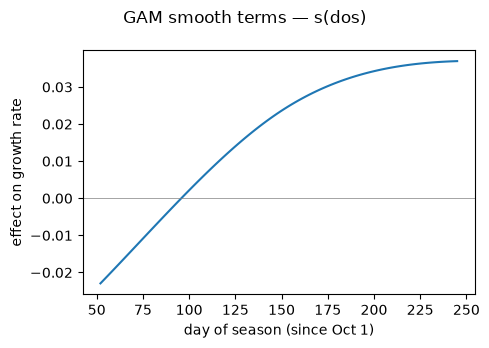

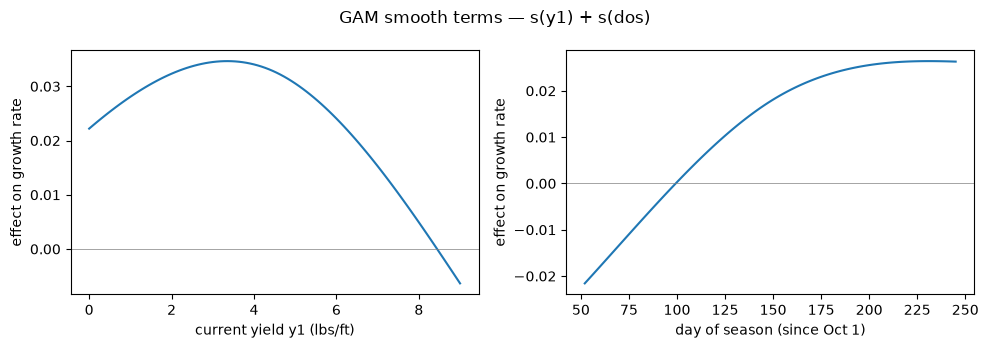

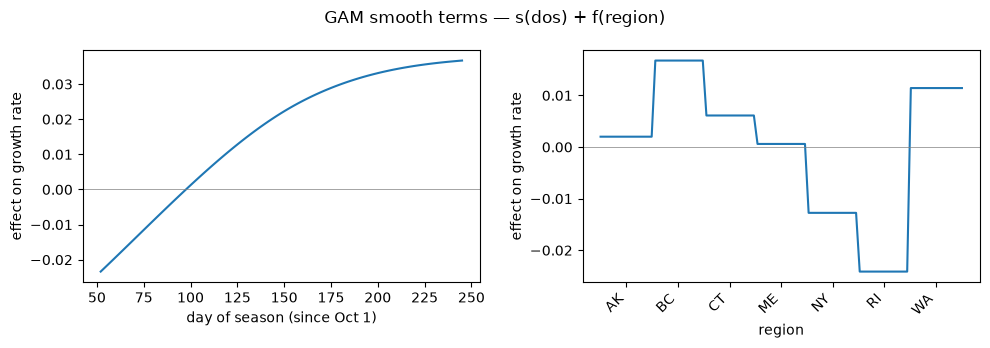

In [89]:
TERM_NAMES = {
    "dos": ["day of season (since Oct 1)"],
    "y1_dos": ["current yield y1 (lbs/ft)", "day of season (since Oct 1)"],
    "dos_region": ["day of season (since Oct 1)", "region"],
    "y1_dos_region": ["current yield y1 (lbs/ft)", "day of season (since Oct 1)", "region"],
}


def plot_partial_dependence(key):
    names = TERM_NAMES[key]
    fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 3.5), squeeze=False)
    for i, (ax, name) in enumerate(zip(axes[0], names)):
        XX = MODELS[key].generate_X_grid(term=i)
        ax.plot(XX[:, i], MODELS[key].partial_dependence(term=i, X=XX))
        ax.axhline(0, color="gray", lw=0.5)
        ax.set_xlabel(name)
        ax.set_ylabel("effect on growth rate")
        if name == "region":
            ax.set_xticks(list(id_to_region))
            ax.set_xticklabels(list(id_to_region.values()), rotation=45, ha="right")
    plt.suptitle(f"GAM smooth terms — {MODEL_LABELS[key]}")
    plt.tight_layout()
    plt.show()


for k in ["dos", "y1_dos", "dos_region"]:
    plot_partial_dependence(k)

### 5.2 Growth rate through the season

Each model vs the constant-rate baseline. For yield-dependent models, rate is evaluated along the model's own expected curve so all models are on the same axis.


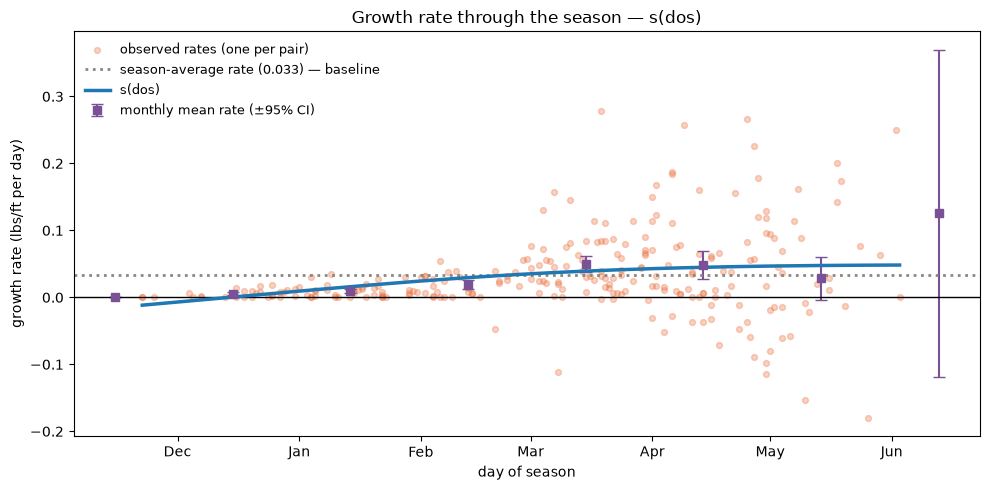

/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2638497074.py:36: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end = pd.Timestamp(seed_date) + pd.Timedelta(days=horizon_days)


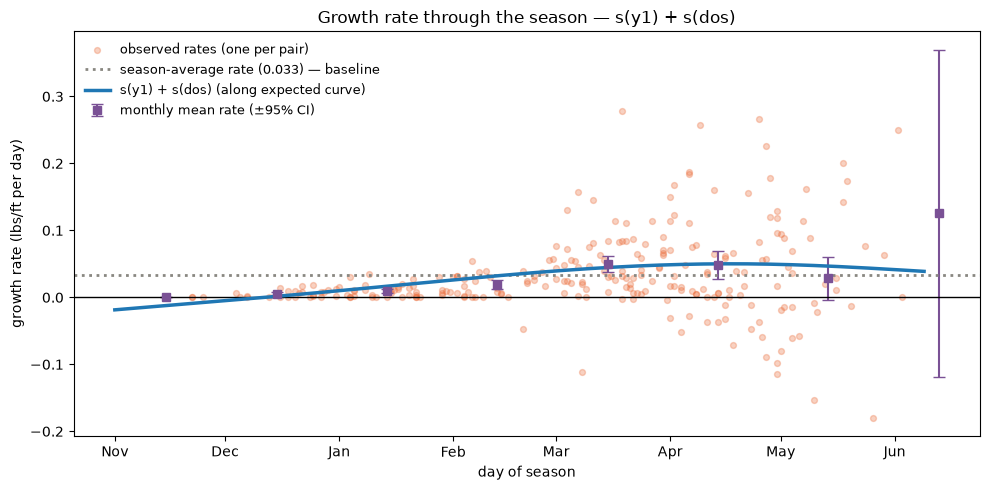

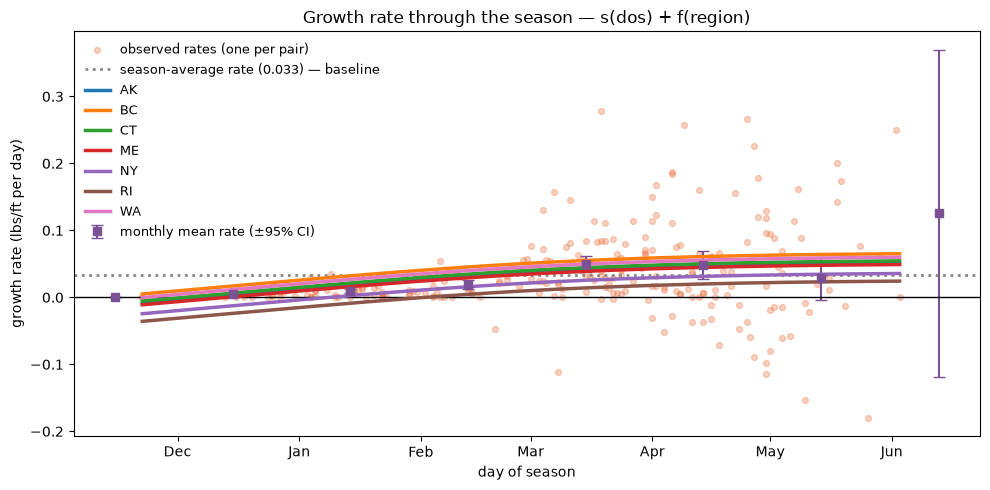

In [90]:
# observed rates + monthly binned means (shared background)
def _rate_plot_background(ax):
    ax.scatter(trainc["dos"], trainc["rate"], s=18, alpha=0.3, color="#eb6834",
               label="observed rates (one per pair)")
    bins = np.arange(30, 271, 30)
    b = trainc.copy()
    b["bin"] = pd.cut(b["dos"], bins)
    bm = b.groupby("bin", observed=True)["rate"].agg(["mean", "sem"])
    centers = [iv.mid for iv in bm.index]
    ax.errorbar(centers, bm["mean"], yerr=1.96 * bm["sem"], fmt="s", color="#7a5195",
                ms=6, capsize=4, label="monthly mean rate (±95% CI)")
    mean_rate = trainc["rate"].mean()
    ax.axhline(mean_rate, color="#898781", lw=2, ls=":",
               label=f"season-average rate ({mean_rate:.3f}) — baseline")
    ax.axhline(0, color="black", lw=1)
    month_starts = pd.date_range("2024-10-01", "2025-06-01", freq="MS")
    ax.set_xticks([(d - pd.Timestamp("2024-10-01")).days for d in month_starts])
    ax.set_xticklabels([d.strftime("%b") for d in month_starts])
    ax.set_xlabel("day of season")
    ax.set_ylabel("growth rate (lbs/ft per day)")


TYPICAL_SEED = pd.Timestamp("2024-11-01")  # a representative outplanting date
dos_grid = np.arange(trainc["dos"].min(), trainc["dos"].max() + 1)


def model_rate_curves(key):
    """Return list of (label, dos array, rate array) curves for one model."""
    curves = []
    if key == "dos":
        curves.append((MODEL_LABELS[key], dos_grid,
                       MODELS[key].predict(dos_grid.reshape(-1, 1))))
    elif key == "dos_region":
        for rid, st in id_to_region.items():
            X = np.column_stack([dos_grid, np.full_like(dos_grid, rid)])
            curves.append((f"{st}", dos_grid, MODELS[key].predict(X)))
    elif key in YIELD_DEPENDENT:
        rid = 0 if "region" in key else None
        curve = project_from_seed(key, TYPICAL_SEED, region_id=rid)
        d = np.array([day_of_season(t) for t in curve.index])
        r = np.array([predict_rate(key, y, t, rid)
                      for t, y in zip(curve.index, curve.values)])
        lbl = MODEL_LABELS[key] + " (along expected curve"
        lbl += f", region={id_to_region[rid]})" if rid is not None else ")"
        curves.append((lbl, d, r))
    return curves


for k in ["dos", "y1_dos", "dos_region"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    _rate_plot_background(ax)
    for lbl, d, r in model_rate_curves(k):
        ax.plot(d, r, lw=2.5, label=lbl)
    ax.legend(frameon=False, fontsize=9)
    ax.set_title(f"Growth rate through the season — {MODEL_LABELS[k]}")
    plt.tight_layout()
    plt.show()

### 5.3 Evaluation

Two protocols on the held-out season:

**A. One-step-ahead.** Anchor at the previous observation, integrate forward, compare to the next observation.

**B. Open-loop from seed.** Integrate from the seed date with no updates. Shows how the model performs with no in-season data.


In [91]:
MEAN_RATE = trainc["rate"].mean()


def eval_onestep(key):
    """Protocol A: project last observation -> next observation, per test pair."""
    rows = []
    for _, r in test_pairs.iterrows():
        pred = project(key, r["d1"], r["y1"], r["Log Date"], r["region_id"])
        rows.append({"obs": r["lbs_ft"], "pred": float(pred.iloc[-1]), "gap": r["gap_days"]})
    return pd.DataFrame(rows)


def eval_openloop(key):
    """Protocol B: project from (seed, 0) once per group, read off at sample dates."""
    rows = []
    test_obs = day_avg[(day_avg["Season"] == TEST_SEASON) & (~day_avg["is_outplant"])]
    for (farm, season, spec), g in test_obs.groupby(GROUP):
        seed = g["seed_date"].iloc[0]
        rid = g["region_id"].iloc[0]
        curve = project(key, seed, 0.0, g["Log Date"].max(), rid)
        for _, r in g.iterrows():
            rows.append({"obs": r["lbs_ft"], "pred": float(curve.loc[r["Log Date"]]),
                         "age": (r["Log Date"] - seed).days})
    return pd.DataFrame(rows)


def eval_baseline_onestep():
    ev = test_pairs.copy()
    ev["pred"] = ev["y1"] + MEAN_RATE * ev["gap_days"]
    return ev.rename(columns={"lbs_ft": "obs"})[["obs", "pred", "gap_days"]]


gam_results = {}
for k in ["dos", "y1_dos", "dos_region"]:
    a, b = eval_onestep(k), eval_openloop(k)
    gam_results[k] = {
        "one-step MAE": (a["pred"] - a["obs"]).abs().mean(),
        "open-loop MAE": (b["pred"] - b["obs"]).abs().mean(),
        "n one-step": len(a),
        "n open-loop": len(b),
    }
bl = eval_baseline_onestep()
gam_results["baseline (y1 + mean rate)"] = {
    "one-step MAE": (bl["pred"] - bl["obs"]).abs().mean(),
    "open-loop MAE": np.nan,
    "n one-step": len(bl),
    "n open-loop": 0,
}
gam_summary = pd.DataFrame(gam_results).T
display(gam_summary.round(3))

,one-step MAE,open-loop MAE,n one-step,n open-loop
dos,0.739,1.111,31.0,42.0
y1_dos,0.778,1.303,31.0,42.0
dos_region,0.744,1.156,31.0,42.0
baseline (y1 + mean rate),1.083,NaN,31.0,0.0


In [92]:
# ---- add y1 + dos + region iff y1 wins the one-step comparison ----
BEST_KEY = "y1_dos" if gam_summary.loc["y1_dos", "one-step MAE"] < gam_summary.loc["dos", "one-step MAE"] else "dos"

if BEST_KEY == "y1_dos":
    print("y1 + dos beats dos on one-step error -> fitting y1 + dos + region")
    MODELS["y1_dos_region"] = LinearGAM(
        s(0, n_splines=N_SPLINES) + s(1, n_splines=N_SPLINES) + f(2)
    ).fit(trainc[["y1", "dos", "region_id"]].values, trainc["rate"].values)

    plot_partial_dependence("y1_dos_region")
    a, b = eval_onestep("y1_dos_region"), eval_openloop("y1_dos_region")
    gam_summary.loc["y1_dos_region"] = {
        "one-step MAE": (a["pred"] - a["obs"]).abs().mean(),
        "open-loop MAE": (b["pred"] - b["obs"]).abs().mean(),
        "n one-step": len(a),
        "n open-loop": len(b),
    }
    if gam_summary.loc["y1_dos_region", "one-step MAE"] < gam_summary.loc["y1_dos", "one-step MAE"]:
        BEST_KEY = "y1_dos_region"
else:
    print("y1 + dos did NOT beat dos on one-step error -> skipping y1_dos_region")

print("BEST_KEY =", BEST_KEY)
display(gam_summary.round(3).sort_values("one-step MAE"))

y1 + dos did NOT beat dos on one-step error -> skipping y1_dos_region
BEST_KEY = dos


,one-step MAE,open-loop MAE,n one-step,n open-loop
dos,0.739,1.111,31.0,42.0
dos_region,0.744,1.156,31.0,42.0
y1_dos,0.778,1.303,31.0,42.0
baseline (y1 + mean rate),1.083,NaN,31.0,0.0


### 5.4 Table 1: actual vs predicted sample

One row per test-season observation: what the best model predicted from the previous observation vs what was actually measured.


In [93]:
def sample_tracking_table(season=TEST_SEASON, model_key=None):
    """One row per test-season observation reached by a one-step-ahead projection."""
    model_key = model_key or BEST_KEY
    part = pairs[pairs["Season"] == season].sort_values(["Farm Name", "Log Date"])
    rows = []
    for _, r in part.iterrows():
        pred = float(
            project(model_key, r["d1"], r["y1"], r["Log Date"], r["region_id"]).iloc[-1]
        )
        rows.append({
            "Farm Name": r["Farm Name"],
            "date": r["Log Date"].date(),
            "dos": day_of_season(r["Log Date"]),
            "event": "harvest" if r["is_harvest"] else "sample",
            "anchor_date": r["d1"].date(),
            "anchor_lbs_ft": r["y1"],
            "gap_days": int(r["gap_days"]),
            "actual_lbs_ft": r["lbs_ft"],
            "pred_lbs_ft": pred,
        })
    t = pd.DataFrame(rows)
    t["error"] = t["pred_lbs_ft"] - t["actual_lbs_ft"]
    return t


sample_tbl = sample_tracking_table()
display(sample_tbl.round(2))
print(f"model = {BEST_KEY}   n = {len(sample_tbl)}   "
      f"MAE = {sample_tbl['error'].abs().mean():.3f} lbs/ft   "
      f"bias = {sample_tbl['error'].mean():+.3f} lbs/ft   "
      f"(positive = overpredicting)")

,Farm Name,date,dos,event,anchor_date,anchor_lbs_ft,gap_days,actual_lbs_ft,pred_lbs_ft,error
0,Farm_12,2025-12-14,74,sample,2025-11-02,0.00,42,0.10,0.00,-0.10
1,Farm_12,2026-01-04,95,sample,2025-12-14,0.10,21,0.22,0.22,0.00
2,Farm_12,2026-02-22,144,sample,2026-01-04,0.22,49,0.81,1.33,0.52
3,Farm_12,2026-02-28,150,sample,2026-02-22,0.81,6,1.03,1.01,-0.02
4,Farm_12,2026-03-15,165,sample,2026-02-28,1.03,15,1.10,1.59,0.49
5,Farm_12,2026-03-28,178,sample,2026-03-15,1.10,13,2.30,1.63,-0.67
6,Farm_12,2026-04-04,185,sample,2026-03-28,2.30,7,2.54,2.61,0.07
7,Farm_12,2026-04-12,193,sample,2026-04-04,2.54,8,2.70,2.89,0.19
8,Farm_12,2026-05-09,220,sample,2026-04-12,2.70,27,3.40,3.95,0.55
9,Farm_12,2026-05-17,228,harvest,2026-05-09,3.40,8,2.50,3.78,1.28


model = dos   n = 31   MAE = 0.739 lbs/ft   bias = +0.284 lbs/ft   (positive = overpredicting)


### 5.5 Project against actual test data

`plot_group_projection(farm, season)` pulls the group's observations, draws the expected curve, and optionally re-projects forward from each observed sample.


['Farm_12' 'Farm_3' 'Farm_39' 'Farm_41' 'Farm_43' 'Farm_52' 'Farm_60'
 'Farm_61' 'Farm_64' 'Farm_68' 'Farm_69' 'Farm_73' 'Farm_76' 'Farm_79'
 'Farm_83']


/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2638497074.py:36: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end = pd.Timestamp(seed_date) + pd.Timedelta(days=horizon_days)
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/780630729.py:31: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end = pd.Timestamp(seed) + pd.Timedelta(days=horizon_days)


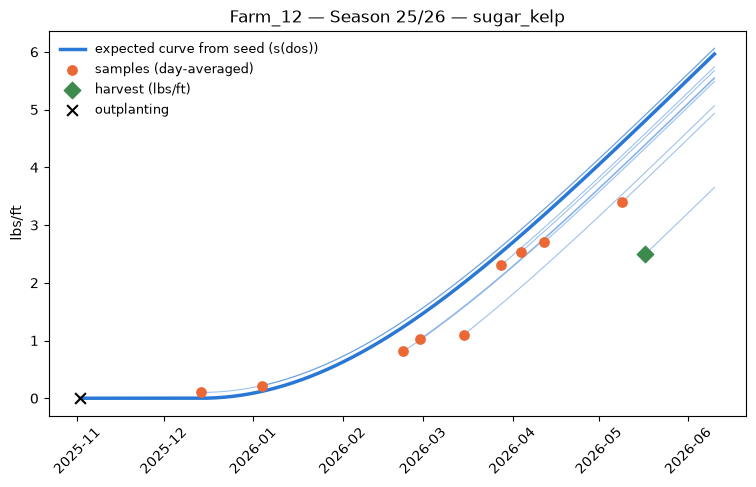

In [94]:
def plot_group_projection(
    farm, season, species=MODEL_SPECIES, model_key=None,
    project_from_anchors=True, horizon_days=HORIZON_DAYS, ax=None,
):
    """Plot one farm-season: observations + model projections.

    project_from_anchors=True additionally draws a projection from each observed
    sample/partial-harvest out to the season horizon (thin lines).
    """
    model_key = model_key or BEST_KEY
    g = day_avg[
        (day_avg["Farm Name"] == farm)
        & (day_avg["Season"] == season)
        & (day_avg["Species"] == species)
    ].sort_values("Log Date")
    if g.empty:
        raise ValueError(f"{farm} / {season} / {species}: no observations after filtering")

    seed = g["seed_date"].iloc[0]
    rid = g["region_id"].iloc[0]
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    # from-seed expected curve
    curve = project_from_seed(model_key, seed, rid, horizon_days)
    ax.plot(curve.index, curve.values, color="#2a78d6", lw=2.5,
            label=f"expected curve from seed ({MODEL_LABELS[model_key]})")

    # projections from each observed anchor
    if project_from_anchors:
        end = pd.Timestamp(seed) + pd.Timedelta(days=horizon_days)
        for _, r in g[~g["is_outplant"]].iterrows():
            c = project(model_key, r["Log Date"], r["lbs_ft"], end, rid)
            ax.plot(c.index, c.values, color="#2a78d6", lw=0.8, alpha=0.45)

    samp = g[(~g["is_outplant"]) & (~g["is_harvest"])]
    ax.scatter(samp["Log Date"], samp["lbs_ft"], color="#eb6834", s=45, zorder=5,
               label="samples (day-averaged)")
    harv = g[g["is_harvest"]]
    if len(harv):
        ax.scatter(harv["Log Date"], harv["lbs_ft"], color="#3d8a4e", marker="D",
                   s=70, zorder=6, label="harvest (lbs/ft)")
    ax.scatter([seed], [0], color="black", marker="x", s=60, zorder=6, label="outplanting")

    ax.set_title(f"{farm} — {season} — {species}")
    ax.set_ylabel("lbs/ft")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9, frameon=False)
    return ax


test_farms = day_avg[day_avg["Season"] == TEST_SEASON]["Farm Name"].unique()
print(test_farms)
plot_group_projection(test_farms[0], TEST_SEASON)
plt.show()

### 5.6 Expected curve by outplanting date


/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2638497074.py:36: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end = pd.Timestamp(seed_date) + pd.Timedelta(days=horizon_days)


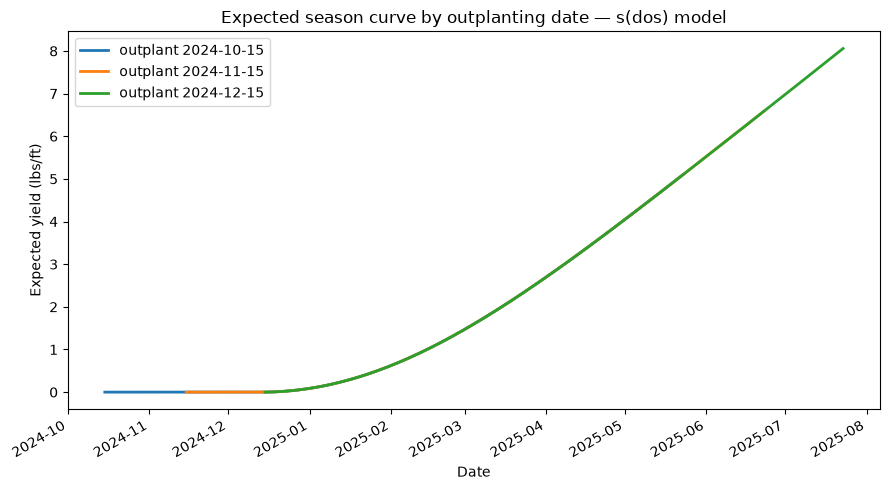

In [95]:
fig, ax = plt.subplots(figsize=(9, 5))
for d0 in ["2024-10-15", "2024-11-15", "2024-12-15"]:
    curve = project_from_seed("dos", d0)
    ax.plot(curve.index, curve.values, lw=2, label=f"outplant {d0}")
ax.set_xlabel("Date")
ax.set_ylabel("Expected yield (lbs/ft)")
ax.legend()
ax.set_title("Expected season curve by outplanting date — s(dos) model")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Harvest calibration

For each harvest event:
1. Take all observations before the harvest (outplant anchor, samples, earlier partial harvests) and project each forward to the harvest date using a rate model.
2. Combine the projections with exponential recency weights (learned τ).
3. Calibrate the weighted projection onto actual harvest lbs/ft using either:
   - **median-ratio coefficient**: one global multiplier
   - **power-law calibration**: lets the ratio vary with prediction size

Everything is packaged per rate model in `fit_harvest_pipeline`.


In [96]:
# calibration observations: day-averaged but keeping same-day sample vs harvest SEPARATE,
# so a harvest's "actual" is never blended with a same-day sample
cal_obs = (
    cal_universe.groupby(
        GROUP + ["seed_date", "region_id", "Log Date", "is_harvest"], as_index=False
    )
    .agg(lbs_ft=("lbs_ft", "mean"), is_outplant=("is_outplant", "max"),
         event_line_ft=("event_line_ft", "sum"))   # harvested line per event (0 for non-harvest)
    .sort_values(GROUP + ["Log Date", "is_harvest"])
    .reset_index(drop=True)
)

grp_lookup = group_info.set_index(GROUP)


def last_obs_info(g, date):
    """The OLD prediction method's inputs: the most recent sample or partial harvest
    strictly before `date` (same-day multiples averaged; outplant zero-anchors excluded).
    Returns dict(lbs_ft, date, is_harvest, gap_days) or None."""
    prior = g[(g["Log Date"] < date) & (~g["is_outplant"])]
    if prior.empty:
        return None
    d = prior["Log Date"].max()
    rows = prior[prior["Log Date"] == d]
    return {"lbs_ft": float(rows["lbs_ft"].mean()), "date": d,
            "is_harvest": bool(rows["is_harvest"].any()),
            "gap_days": int((date - d).days)}


def last_obs_lbs_ft(g, date):
    info = last_obs_info(g, date)
    return np.nan if info is None else info["lbs_ft"]


def build_harvest_events(model_key, seasons=None, harvest_anchor_div=1.0, pred_mult=1.0):
    """One record per harvest event: actual lbs/ft + arrays of (gap, projected endpoint)
    for every anchor strictly before it, using the given rate model's projections.

    Scale-fixed pipelines pass harvest_anchor_div=SCALE (prior-harvest anchors are converted
    to sample scale before projecting) and pred_mult=SCALE (sample-scale projections are
    converted back to harvest scale, so stored preds are always comparable to actual)."""
    recs = []
    for (farm, season, spec), g in cal_obs.groupby(GROUP):
        if seasons is not None and season not in seasons:
            continue
        g = g.sort_values(["Log Date", "is_harvest"])
        rid = g["region_id"].iloc[0]
        h_rows = g[g["is_harvest"]]
        if h_rows.empty:
            continue
        gi = grp_lookup.loc[(farm, season, spec)]
        for _, h in h_rows.iterrows():
            prior = g[g["Log Date"] < h["Log Date"]]
            if prior.empty or prior["lbs_ft"].max() == 0:
                continue  # need at least one real observation beyond the zero anchor
            gaps, preds = [], []
            for _, a in prior.iterrows():
                gap = (h["Log Date"] - a["Log Date"]).days
                if gap < 1:
                    continue
                a_val = a["lbs_ft"] / harvest_anchor_div if a["is_harvest"] else a["lbs_ft"]
                p = pred_mult * float(
                    project(model_key, a["Log Date"], a_val, h["Log Date"], rid).iloc[-1]
                )
                gaps.append(gap)
                preds.append(p)
            if not preds:
                continue
            # the OLD method's inputs + its projected version (rung L2 of the ladder):
            # same anchor the old method uses, but pushed to the harvest date by this
            # pipeline's rate model (with the pipeline's scale transforms honored)
            lo = last_obs_info(g, h["Log Date"])
            if lo is not None:
                lo_model = (lo["lbs_ft"] / harvest_anchor_div if lo["is_harvest"]
                            else lo["lbs_ft"])
                pred_lo_proj = pred_mult * float(
                    project(model_key, lo["date"], lo_model, h["Log Date"], rid).iloc[-1]
                )
            else:
                pred_lo_proj = np.nan
            recs.append({
                "Farm Name": farm, "Season": season, "Species": spec,
                "harvest_date": h["Log Date"],
                "actual_lbs_ft": h["lbs_ft"],
                "gaps": np.array(gaps, dtype=float),
                "preds": np.array(preds, dtype=float),
                "n_anchors": len(preds),
                "last_obs_lbs_ft": lo["lbs_ft"] if lo else np.nan,
                "last_obs_gap_days": lo["gap_days"] if lo else np.nan,
                "last_obs_is_harvest": bool(lo["is_harvest"]) if lo else False,
                "pred_last_obs_projected": pred_lo_proj,
                "event_line_ft": float(h["event_line_ft"]),
                "harvest_line_ft_group": float(gi["harvest_line_ft"]),
                "true_biomass_lbs_group": float(gi["true_biomass_lbs"]),
                "n_harvests_in_group": int(gi["n_harvests"]),
                "is_final_harvest": h["Log Date"] == gi["last_harvest_date"],
                "group_is_total_harvest": bool(gi["flag_total_harvest"]),
                "group_true_yield_lbs_ft": gi["true_yield_lbs_ft"],
            })
    return pd.DataFrame(recs)

### 6.1 Pipeline pieces: recency weights and both calibrations


In [97]:
# ---- weight family ----
def w_expdecay(gap, tau):
    """Exponential decay with time-scale tau days."""
    return np.exp(-np.asarray(gap, dtype=float) / tau)


def weighted_pred(rec, wfn, param):
    w = wfn(rec["gaps"], param)
    if w.sum() <= 0:
        w = np.zeros_like(w); w[np.argmin(rec["gaps"])] = 1.0
    return float(np.sum(w * rec["preds"]) / np.sum(w))


def all_weighted_preds(events_df, wfn, param):
    return np.array([weighted_pred(r, wfn, param) for _, r in events_df.iterrows()])


def fit_coeff(events_df, wfn, param):
    """Median-ratio coefficient + calibrated MAE on the given events."""
    wp = all_weighted_preds(events_df, wfn, param)
    actual = events_df["actual_lbs_ft"].values
    ok = wp > 0
    coeff = float(np.median(actual[ok] / wp[ok]))
    mae = float(np.abs(coeff * wp - actual).mean())
    return coeff, mae, wp


def fit_param_calibration(events_df, wfn, param):
    """Robust log-log fit: log(actual) = alpha + beta * log(weighted_pred)."""
    wp = all_weighted_preds(events_df, wfn, param)
    actual = events_df["actual_lbs_ft"].values
    ok = (wp > 0) & (actual > 0)
    lx, ly = np.log(wp[ok]), np.log(actual[ok])

    def resid(p):
        return (p[0] + p[1] * lx) - ly

    fit = least_squares(resid, x0=[np.log(max(np.median(actual[ok] / wp[ok]), 1e-6)), 1.0],
                        loss="soft_l1", f_scale=0.3)
    alpha, beta = fit.x

    def apply_cal(pred):
        pred = np.asarray(pred, dtype=float)
        return np.exp(alpha) * np.maximum(pred, 1e-9) ** beta

    train_mae = float(np.abs(apply_cal(wp[ok]) - actual[ok]).mean())
    return {"alpha": float(alpha), "beta": float(beta),
            "apply": apply_cal, "train_mae": train_mae, "n": int(ok.sum())}

### 6.2 fit_harvest_pipeline

One call per rate model. Each pipeline carries its own τ, both calibrations, and train/test harvest events.


In [98]:
from scipy.optimize import minimize_scalar


def tau_loss(tau, events_df):
    _, mae, _ = fit_coeff(events_df, w_expdecay, tau)   # coeff refits inside — joint fit
    return mae


def fit_harvest_pipeline(model_key, harvest_anchor_div=1.0, pred_mult=1.0, verbose=True):
    """Fit the full harvest-prediction stack for ONE rate model.

    Returns a dict with: model_key, tau, coeff_single, coeff_all, param_cal,
    train_events, test_events, wp_train (weighted projections on train), plus the
    scale transforms (harvest_anchor_div, pred_mult) so downstream functions honor them.
    """
    train_ev = build_harvest_events(model_key, seasons=set(cal_obs["Season"]) - {TEST_SEASON},
                                    harvest_anchor_div=harvest_anchor_div, pred_mult=pred_mult)
    test_ev = build_harvest_events(model_key, seasons={TEST_SEASON},
                                   harvest_anchor_div=harvest_anchor_div, pred_mult=pred_mult)

    res = minimize_scalar(tau_loss, bounds=(2, 240), method="bounded",
                          args=(train_ev,), options={"xatol": 0.5})
    tau = float(res.x)

    train_single = train_ev[train_ev["n_harvests_in_group"] == 1]
    coeff_single, _, _ = fit_coeff(train_single, w_expdecay, tau)
    coeff_all, train_mae_median, wp_train = fit_coeff(train_ev, w_expdecay, tau)
    param_cal = fit_param_calibration(train_ev, w_expdecay, tau)

    pipe = {
        "model_key": model_key, "tau": tau,
        "coeff_single": coeff_single, "coeff_all": coeff_all,
        "train_mae_median": train_mae_median, "param_cal": param_cal,
        "train_events": train_ev, "test_events": test_ev, "wp_train": wp_train,
        "harvest_anchor_div": harvest_anchor_div, "pred_mult": pred_mult,
    }
    if verbose:
        print(f"{model_key:15s} tau={tau:6.1f}d  coeff_single={coeff_single:.3f}  "
              f"coeff_all={coeff_all:.3f}  "
              f"param: {np.exp(param_cal['alpha']):.3f}·pred^{param_cal['beta']:.2f}  "
              f"train MAE (median cal): {train_mae_median:.3f}  "
              f"(param cal): {param_cal['train_mae']:.3f}  "
              f"[n_train={len(train_ev)}, n_test={len(test_ev)}]")
    return pipe


# the pooled curve, the region-specific curves, and whatever won the sample-level protocol
HARVEST_MODEL_KEYS = list(dict.fromkeys(["dos", "dos_region", BEST_KEY]))
PIPELINES = {k: fit_harvest_pipeline(k) for k in HARVEST_MODEL_KEYS}

dos             tau=  20.8d  coeff_single=0.566  coeff_all=0.811  param: 0.566·pred^1.24  train MAE (median cal): 1.419  (param cal): 1.432  [n_train=206, n_test=75]
dos_region      tau=  22.6d  coeff_single=0.559  coeff_all=0.796  param: 0.572·pred^1.23  train MAE (median cal): 1.433  (param cal): 1.440  [n_train=206, n_test=75]


### 6.2b Scale-fixed variant

Samples and harvests measure on different scales. This variant converts harvests to sample scale first (SCALE estimated from near-in-time sample-harvest pairs), so the trailing calibration should print near 1 as a sanity check. Also removes the spurious late-season rate droop that mixed-scale pairs teach the GAM.


sample-only rate pairs: 199 of 256
SCALE (harvest / sample-scale) = 0.652   [n=152, IQR 0.42-0.84, median gap 20d]
for comparison — dos pipeline calibration coeff: 0.811


/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/1059415947.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & (~trainc["is_harvest1"].fillna(False).astype(bool))


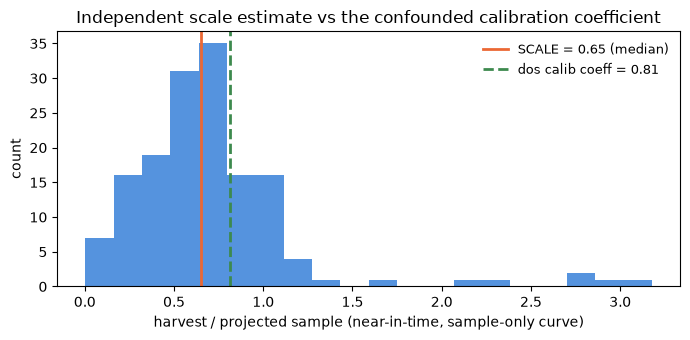

In [99]:
MAX_SCALE_GAP = 45   # days: last sample must be within this window of the harvest

# ---- sample-only rate curve: no harvest at EITHER endpoint of a pair ----
sample_pairs = trainc[
    (~trainc["is_harvest"].astype(bool))
    & (~trainc["is_harvest1"].fillna(False).astype(bool))
]
print(f"sample-only rate pairs: {len(sample_pairs)} of {len(trainc)}")
MODELS["dos_sample_only"] = LinearGAM(s(0, n_splines=N_SPLINES)).fit(
    sample_pairs[["dos"]].values, sample_pairs["rate"].values
)
FEATURES["dos_sample_only"] = lambda y, d, r: [day_of_season(d)]
MODEL_LABELS["dos_sample_only"] = "s(dos), sample-only pairs"


def estimate_scale(max_gap_days=MAX_SCALE_GAP):
    """Median(actual harvest / sample projected to harvest date) over TRAIN seasons,
    using the sample-only curve and only near-in-time (<= max_gap_days) samples."""
    rows = []
    train_seasons = set(cal_obs["Season"]) - {TEST_SEASON}
    for (farm, season, spec), g in cal_obs.groupby(GROUP):
        if season not in train_seasons:
            continue
        g = g.sort_values(["Log Date", "is_harvest"])
        rid = g["region_id"].iloc[0]
        for _, h in g[g["is_harvest"]].iterrows():
            prior_samp = g[(g["Log Date"] < h["Log Date"])
                           & (~g["is_harvest"]) & (~g["is_outplant"])
                           & (g["lbs_ft"] > 0)]
            if prior_samp.empty:
                continue
            a = prior_samp.iloc[-1]
            gap = (h["Log Date"] - a["Log Date"]).days
            if not (1 <= gap <= max_gap_days):
                continue
            proj = float(project("dos_sample_only", a["Log Date"], a["lbs_ft"],
                                 h["Log Date"], rid).iloc[-1])
            if proj > 0:
                rows.append({"Farm Name": farm, "Season": season, "gap_days": gap,
                             "sample_lbs_ft": a["lbs_ft"], "projected": proj,
                             "harvest_lbs_ft": h["lbs_ft"],
                             "ratio": h["lbs_ft"] / proj})
    return pd.DataFrame(rows)


scale_obs = estimate_scale()
if len(scale_obs) >= 5:
    SCALE = float(scale_obs["ratio"].median())
else:
    print(f"WARNING: only {len(scale_obs)} near-in-time sample->harvest comparisons; "
          f"falling back to the dos pipeline's median coefficient as SCALE")
    SCALE = PIPELINES["dos"]["coeff_all"]

q25, q75 = (scale_obs["ratio"].quantile([0.25, 0.75]) if len(scale_obs) else (np.nan, np.nan))
print(f"SCALE (harvest / sample-scale) = {SCALE:.3f}   "
      f"[n={len(scale_obs)}, IQR {q25:.2f}-{q75:.2f}, median gap "
      f"{scale_obs['gap_days'].median() if len(scale_obs) else np.nan:.0f}d]")
print(f"for comparison — dos pipeline calibration coeff: {PIPELINES['dos']['coeff_all']:.3f}")

if len(scale_obs):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(scale_obs["ratio"], bins=20, color="#2a78d6", alpha=0.8)
    ax.axvline(SCALE, color="#eb6834", lw=2, label=f"SCALE = {SCALE:.2f} (median)")
    ax.axvline(PIPELINES["dos"]["coeff_all"], color="#3d8a4e", lw=2, ls="--",
               label=f"dos calib coeff = {PIPELINES['dos']['coeff_all']:.2f}")
    ax.set_xlabel("harvest / projected sample (near-in-time, sample-only curve)")
    ax.set_ylabel("count")
    ax.legend(frameon=False, fontsize=9)
    ax.set_title("Independent scale estimate vs the confounded calibration coefficient")
    plt.tight_layout()
    plt.show()

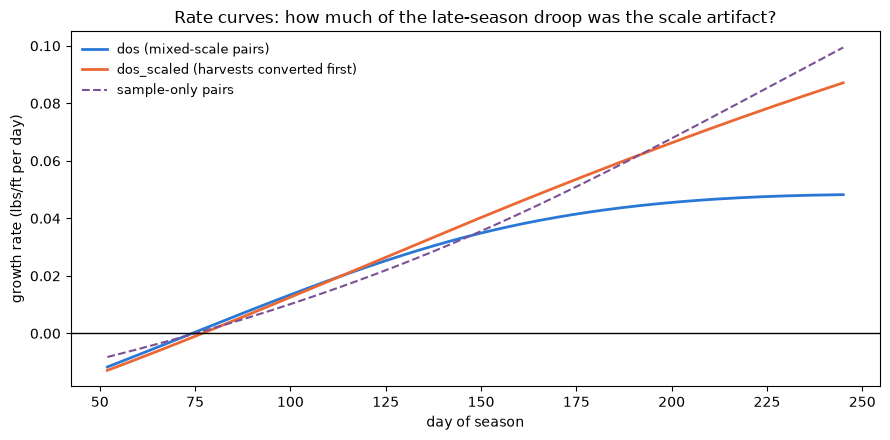

dos_scaled      tau=   2.3d  coeff_single=0.716  coeff_all=0.958  param: 0.872·pred^1.04  train MAE (median cal): 1.293  (param cal): 1.305  [n_train=206, n_test=75]


In [100]:
# ---- refit the rate model on scale-fixed data, and add the scaled pipeline ----
# harvests converted to sample scale BEFORE rate pairs are formed, so sample->harvest
# pairs no longer teach the GAM a fake late-season crash
model_events_scaled = model_events.copy()
model_events_scaled.loc[model_events_scaled["is_harvest"], "lbs_ft"] /= SCALE
*_, trainc_scaled = build_rate_observations(model_events_scaled)

MODELS["dos_scaled"] = LinearGAM(s(0, n_splines=N_SPLINES)).fit(
    trainc_scaled[["dos"]].values, trainc_scaled["rate"].values
)
FEATURES["dos_scaled"] = lambda y, d, r: [day_of_season(d)]
MODEL_LABELS["dos_scaled"] = "s(dos), harvests /SCALE"

# how much did de-scaling the harvests move the late-season rate curve?
fig, ax = plt.subplots(figsize=(9, 4.5))
grid = np.arange(trainc["dos"].min(), trainc["dos"].max() + 1)
ax.plot(grid, MODELS["dos"].predict(grid.reshape(-1, 1)), lw=2, color="#2a78d6",
        label="dos (mixed-scale pairs)")
ax.plot(grid, MODELS["dos_scaled"].predict(grid.reshape(-1, 1)), lw=2, color="#eb6834",
        label="dos_scaled (harvests converted first)")
ax.plot(grid, MODELS["dos_sample_only"].predict(grid.reshape(-1, 1)), lw=1.5, ls="--",
        color="#7a5195", label="sample-only pairs")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("day of season")
ax.set_ylabel("growth rate (lbs/ft per day)")
ax.set_title("Rate curves: how much of the late-season droop was the scale artifact?")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# the scaled pipeline: sample-scale everywhere inside, x SCALE at the end.
# If SCALE captured the whole bias, coeff_all should print ~1 and beta ~1.
PIPELINES["dos_scaled"] = fit_harvest_pipeline(
    "dos_scaled", harvest_anchor_div=SCALE, pred_mult=SCALE
)

### 6.3 Held-out evaluation

Every model x every calibration on the same held-out season. `OLD: last obs` is the benchmark.


In [101]:
def eval_pipeline(pipe):
    """Held-out metrics for one pipeline, one row per calibration variant."""
    te = pipe["test_events"]
    if not len(te):
        return pd.DataFrame()
    wp = all_weighted_preds(te, w_expdecay, pipe["tau"])
    actual = te["actual_lbs_ft"].values
    variants = {
        "uncalibrated": wp,
        "median (single-harvest fit)": pipe["coeff_single"] * wp,
        "median (all events)": pipe["coeff_all"] * wp,
        "param (log-log)": pipe["param_cal"]["apply"](wp),
    }
    rows = []
    for name, pred in variants.items():
        err = pred - actual
        rows.append({
            "model": pipe["model_key"], "calibration": name,
            "MAE": float(np.abs(err).mean()), "bias": float(err.mean()),
            "med_ratio": float(np.median(pred / actual)), "n": len(te),
        })
    return pd.DataFrame(rows)


held_out = pd.concat([eval_pipeline(p) for p in PIPELINES.values()], ignore_index=True)

# the OLD method as the benchmark row: last sample/partial harvest carried forward, as-is.
# Model-independent (same events for every pipeline), so it appears once.
_te = PIPELINES["dos"]["test_events"]
if len(_te):
    _lo = _te["last_obs_lbs_ft"].values
    _ac = _te["actual_lbs_ft"].values
    _ok = np.isfinite(_lo)
    _err = _lo[_ok] - _ac[_ok]
    held_out = pd.concat([held_out, pd.DataFrame([{
        "model": "OLD: last obs", "calibration": "as-is",
        "MAE": float(np.abs(_err).mean()), "bias": float(_err.mean()),
        "med_ratio": float(np.median(_lo[_ok] / _ac[_ok])), "n": int(_ok.sum()),
    }])], ignore_index=True)

print(f"--- {TEST_SEASON} ---")
display(held_out.round(3))
print("\nMAE, models x calibrations:")
display(held_out.pivot(index="model", columns="calibration", values="MAE").round(3))

--- Season 25/26 ---


,model,calibration,MAE,bias,med_ratio,n
0,dos,uncalibrated,1.186,0.543,1.206,75
1,dos,median (single-harvest fit),1.358,-1.171,0.682,75
2,dos,median (all events),1.062,-0.203,0.978,75
3,dos,param (log-log),1.091,-0.279,0.945,75
4,dos_region,uncalibrated,1.185,0.559,1.224,75
5,dos_region,median (single-harvest fit),1.369,-1.188,0.684,75
6,dos_region,median (all events),1.060,-0.250,0.974,75
7,dos_region,param (log-log),1.086,-0.248,0.950,75
8,dos_scaled,uncalibrated,0.905,0.086,1.027,75
9,dos_scaled,median (single-harvest fit),1.119,-0.905,0.735,75



MAE, models x calibrations:


calibration,as-is,median (all events),median (single-harvest fit),param (log-log),uncalibrated
model,,,,,
OLD: last obs,1.043,NaN,NaN,NaN,NaN
dos,NaN,1.062,1.358,1.091,1.186
dos_region,NaN,1.060,1.369,1.086,1.185
dos_scaled,NaN,0.893,1.119,0.904,0.905


### 6.3b Ablation ladder

Breaks down which ingredients beat the old method and which hurt. Useful when the full model loses to "just use the last sample."


In [102]:
def ladder_table(pipe):
    """Nested variants from the OLD method to the full pipeline, held-out scored.
    Median coefficients for L1b/L3 are fit on the pipeline's TRAIN events."""
    tr, te = pipe["train_events"], pipe["test_events"]
    if not len(te):
        return pd.DataFrame()

    def med_coeff(pred_tr):
        ok = np.isfinite(pred_tr) & (pred_tr > 0)
        return float(np.median(tr["actual_lbs_ft"].values[ok] / pred_tr[ok]))

    wp_te = all_weighted_preds(te, w_expdecay, pipe["tau"])
    rungs = [
        ("L1  last obs, as-is (OLD)",             te["last_obs_lbs_ft"].values, 1.0),
        ("L1b last obs x median coeff",           te["last_obs_lbs_ft"].values,
                                                  med_coeff(tr["last_obs_lbs_ft"].values)),
        ("L2  last obs projected, as-is",         te["pred_last_obs_projected"].values, 1.0),
        ("L3  last obs projected x median coeff", te["pred_last_obs_projected"].values,
                                                  med_coeff(tr["pred_last_obs_projected"].values)),
        ("L4  weighted anchors x median coeff",   wp_te, pipe["coeff_all"]),
    ]
    actual = te["actual_lbs_ft"].values
    rows = []
    for name, pred, c in rungs:
        p = c * np.asarray(pred, dtype=float)
        ok = np.isfinite(p) & (actual > 0)
        err = p[ok] - actual[ok]
        rows.append({"rung": name, "coeff": round(c, 3),
                     "MAE": float(np.abs(err).mean()), "bias": float(err.mean()),
                     "med_ratio": float(np.median(p[ok] / actual[ok])), "n": int(ok.sum())})
    return pd.DataFrame(rows)


for k in dict.fromkeys(["dos", "dos_scaled", BEST_KEY]):
    if k in PIPELINES:
        print(f"===== ladder: {k} =====")
        display(ladder_table(PIPELINES[k]).round(3))
        print()

# ---- why the OLD row's bias looks smaller than the historical ~2x ----
# its error, split by what the last observation was (train + test events pooled for n)
_all_ev = pd.concat([PIPELINES["dos"]["train_events"], PIPELINES["dos"]["test_events"]],
                    ignore_index=True)
_all_ev = _all_ev[np.isfinite(_all_ev["last_obs_lbs_ft"])].copy()
_all_ev["lo_type"] = np.where(_all_ev["last_obs_is_harvest"], "partial harvest", "sample")
_all_ev["err_old"] = _all_ev["last_obs_lbs_ft"] - _all_ev["actual_lbs_ft"]
_all_ev["ratio_old"] = _all_ev["last_obs_lbs_ft"] / _all_ev["actual_lbs_ft"]
print("OLD-method error by last-observation type (all seasons):")
display(
    _all_ev.groupby("lo_type")
    .agg(n=("err_old", "size"),
         MAE=("err_old", lambda e: e.abs().mean()),
         bias=("err_old", "mean"),
         med_ratio=("ratio_old", "median"),
         med_gap_days=("last_obs_gap_days", "median"))
    .round(2)
)
# and by gap length within sample-anchored events: short gaps ~= pure scale optimism,
# long gaps let real growth offset it
_samp = _all_ev[_all_ev["lo_type"] == "sample"].copy()
if len(_samp) >= 4:
    _samp["gap_bin"] = pd.cut(_samp["last_obs_gap_days"], bins=[0, 14, 30, 60, 365],
                              labels=["<=14d", "15-30d", "31-60d", ">60d"])
    print("\nsample-anchored OLD errors by gap to harvest:")
    display(_samp.groupby("gap_bin", observed=True)
            .agg(n=("err_old", "size"), bias=("err_old", "mean"),
                 med_ratio=("ratio_old", "median")).round(2))

===== ladder: dos =====


,rung,coeff,MAE,bias,med_ratio,n
0,"L1 last obs, as-is (OLD)",1.000,1.043,-0.046,0.988,75
1,L1b last obs x median coeff,1.000,1.043,-0.045,0.988,75
2,"L2 last obs projected, as-is",1.000,1.102,0.305,1.108,75
3,L3 last obs projected x median coeff,0.847,1.045,-0.261,0.939,75
4,L4 weighted anchors x median coeff,0.811,1.062,-0.203,0.978,75



===== ladder: dos_scaled =====


,rung,coeff,MAE,bias,med_ratio,n
0,"L1 last obs, as-is (OLD)",1.000,1.043,-0.046,0.988,75
1,L1b last obs x median coeff,1.000,1.043,-0.045,0.988,75
2,"L2 last obs projected, as-is",1.000,0.900,0.079,1.026,75
3,L3 last obs projected x median coeff,0.962,0.889,-0.052,0.987,75
4,L4 weighted anchors x median coeff,0.958,0.893,-0.061,0.983,75



OLD-method error by last-observation type (all seasons):


,n,MAE,bias,med_ratio,med_gap_days
lo_type,,,,,
partial harvest,184,1.05,-0.03,0.98,3.0
sample,97,1.63,0.19,1.21,14.0



sample-anchored OLD errors by gap to harvest:


,n,bias,med_ratio
gap_bin,,,
<=14d,51,0.98,1.32
15-30d,22,-0.69,1.08
31-60d,19,-0.54,0.95
>60d,5,-1.19,0.46


### 6.4 Choose the working pipeline

`HARVEST_MODEL` and `CAL_MODE` are the two switches everything downstream reads.


In [103]:
HARVEST_MODEL = "dos_scaled"    # any key in PIPELINES, e.g. "dos_region" for region curves
CAL_MODE = "median_all"      # one of: "median_single", "median_all", "param"

HARVEST_PIPE = PIPELINES[HARVEST_MODEL]


def calibrate(pred, pipe=None, mode=None):
    """Apply a pipeline's calibration to raw weighted projection(s)."""
    pipe = pipe or HARVEST_PIPE
    mode = mode or CAL_MODE
    pred = np.asarray(pred, dtype=float)
    if mode == "median_single":
        out = pipe["coeff_single"] * pred
    elif mode == "median_all":
        out = pipe["coeff_all"] * pred
    elif mode == "param":
        out = pipe["param_cal"]["apply"](pred)
    else:
        raise ValueError(f"unknown CAL_MODE {mode!r}")
    return float(out) if out.ndim == 0 else out


print(f"working pipeline: model={HARVEST_MODEL}  tau={HARVEST_PIPE['tau']:.1f}d  cal={CAL_MODE}")

working pipeline: model=dos_scaled  tau=2.3d  cal=median_all


### 6.5 Table 2: actual vs predicted harvest

One row per held-out harvest: raw projection, both calibrated predictions, and actual.


In [104]:
def harvest_table(pipe=None, events_df=None):
    """Per-harvest table for one pipeline: raw weighted projection + both calibrations vs actual."""
    pipe = pipe or HARVEST_PIPE
    events_df = pipe["test_events"] if events_df is None else events_df
    rows = []
    for _, r in events_df.iterrows():
        wp = weighted_pred(r, w_expdecay, pipe["tau"])
        rows.append({
            "Farm Name": r["Farm Name"],
            "Season": r["Season"],
            "harvest_date": r["harvest_date"].date(),
            "dos": day_of_season(r["harvest_date"]),
            "n_anchors": r["n_anchors"],
            "actual_lbs_ft": r["actual_lbs_ft"],
            "pred_raw": wp,
            "pred_median_cal": pipe["coeff_all"] * wp,
            "pred_param_cal": float(pipe["param_cal"]["apply"](wp)),
            "pred_last_obs": r["last_obs_lbs_ft"],
        })
    t = pd.DataFrame(rows).sort_values(["Farm Name", "harvest_date"]).reset_index(drop=True)
    t["err_median"] = t["pred_median_cal"] - t["actual_lbs_ft"]
    t["err_param"] = t["pred_param_cal"] - t["actual_lbs_ft"]
    t["err_last_obs"] = t["pred_last_obs"] - t["actual_lbs_ft"]
    return t


for key, pipe in PIPELINES.items():
    tbl = harvest_table(pipe)
    print(f"===== model: {key} =====")
    display(tbl.round(2))
    for col, name in [("err_median", "(a) median coeff"), ("err_param", "(b) parameterized"),
                      ("err_last_obs", "OLD: last obs (as-is)")]:
        e = tbl[col].dropna()
        print(f"{name:22s} MAE = {e.abs().mean():.3f}   "
              f"bias = {e.mean():+.3f}   "
              f"% overestimated = {(e > 0).mean():.0%}")
    print()

harvest_tbl = harvest_table()   # the working pipeline's table, kept around by name

===== model: dos =====


,Farm Name,Season,harvest_date,dos,n_anchors,actual_lbs_ft,pred_raw,pred_median_cal,pred_param_cal,pred_last_obs,err_median,err_param,err_last_obs
0,Farm_1,Season 25/26,2026-04-27,208,4,0.78,2.62,2.12,1.86,2.33,1.34,1.08,1.55
1,Farm_1,Season 25/26,2026-05-24,235,5,3.63,2.89,2.34,2.10,0.78,-1.29,-1.53,-2.85
2,Farm_1,Season 25/26,2026-05-28,239,6,4.18,3.58,2.90,2.73,3.63,-1.28,-1.44,-0.55
3,Farm_1,Season 25/26,2026-05-29,240,7,4.49,3.89,3.16,3.04,4.18,-1.33,-1.45,-0.31
4,Farm_1,Season 25/26,2026-06-10,252,8,7.06,4.66,3.78,3.80,4.49,-3.27,-3.26,-2.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Farm_80,Season 25/26,2026-06-09,251,15,3.75,4.52,3.67,3.65,1.71,-0.08,-0.10,-2.04
71,Farm_80,Season 25/26,2026-06-10,252,16,3.43,4.46,3.62,3.60,3.75,0.19,0.17,0.32
72,Farm_83,Season 25/26,2026-04-21,202,3,1.83,3.22,2.61,2.40,1.80,0.78,0.57,-0.03
73,Farm_83,Season 25/26,2026-05-18,229,5,5.08,3.54,2.87,2.70,2.80,-2.21,-2.38,-2.28


(a) median coeff       MAE = 1.062   bias = -0.203   % overestimated = 48%
(b) parameterized      MAE = 1.091   bias = -0.279   % overestimated = 43%
OLD: last obs (as-is)  MAE = 1.043   bias = -0.046   % overestimated = 48%

===== model: dos_region =====


,Farm Name,Season,harvest_date,dos,n_anchors,actual_lbs_ft,pred_raw,pred_median_cal,pred_param_cal,pred_last_obs,err_median,err_param,err_last_obs
0,Farm_1,Season 25/26,2026-04-27,208,4,0.78,2.63,2.10,1.89,2.33,1.31,1.10,1.55
1,Farm_1,Season 25/26,2026-05-24,235,5,3.63,2.97,2.37,2.19,0.78,-1.26,-1.44,-2.85
2,Farm_1,Season 25/26,2026-05-28,239,6,4.18,3.59,2.86,2.76,3.63,-1.32,-1.41,-0.55
3,Farm_1,Season 25/26,2026-05-29,240,7,4.49,3.89,3.10,3.05,4.18,-1.39,-1.44,-0.31
4,Farm_1,Season 25/26,2026-06-10,252,8,7.06,4.69,3.73,3.83,4.49,-3.33,-3.22,-2.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Farm_80,Season 25/26,2026-06-09,251,15,3.75,4.59,3.65,3.74,1.71,-0.10,-0.01,-2.04
71,Farm_80,Season 25/26,2026-06-10,252,16,3.43,4.53,3.60,3.68,3.75,0.18,0.25,0.32
72,Farm_83,Season 25/26,2026-04-21,202,3,1.83,3.21,2.55,2.41,1.80,0.72,0.58,-0.03
73,Farm_83,Season 25/26,2026-05-18,229,5,5.08,3.56,2.83,2.73,2.80,-2.25,-2.35,-2.28


(a) median coeff       MAE = 1.060   bias = -0.250   % overestimated = 47%
(b) parameterized      MAE = 1.086   bias = -0.248   % overestimated = 41%
OLD: last obs (as-is)  MAE = 1.043   bias = -0.046   % overestimated = 48%

===== model: dos_scaled =====


,Farm Name,Season,harvest_date,dos,n_anchors,actual_lbs_ft,pred_raw,pred_median_cal,pred_param_cal,pred_last_obs,err_median,err_param,err_last_obs
0,Farm_1,Season 25/26,2026-04-27,208,4,0.78,2.05,1.96,1.84,2.33,1.18,1.06,1.55
1,Farm_1,Season 25/26,2026-05-24,235,5,3.63,2.14,2.05,1.93,0.78,-1.58,-1.70,-2.85
2,Farm_1,Season 25/26,2026-05-28,239,6,4.18,3.85,3.69,3.55,3.63,-0.49,-0.63,-0.55
3,Farm_1,Season 25/26,2026-05-29,240,7,4.49,4.18,4.01,3.87,4.18,-0.48,-0.62,-0.31
4,Farm_1,Season 25/26,2026-06-10,252,8,7.06,5.04,4.83,4.70,4.49,-2.22,-2.35,-2.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Farm_80,Season 25/26,2026-06-09,251,15,3.75,2.57,2.46,2.33,1.71,-1.29,-1.42,-2.04
71,Farm_80,Season 25/26,2026-06-10,252,16,3.43,3.37,3.23,3.09,3.75,-0.20,-0.33,0.32
72,Farm_83,Season 25/26,2026-04-21,202,3,1.83,2.45,2.34,2.21,1.80,0.51,0.39,-0.03
73,Farm_83,Season 25/26,2026-05-18,229,5,5.08,2.77,2.66,2.52,2.80,-2.42,-2.56,-2.28


(a) median coeff       MAE = 0.893   bias = -0.061   % overestimated = 48%
(b) parameterized      MAE = 0.904   bias = -0.189   % overestimated = 44%
OLD: last obs (as-is)  MAE = 1.043   bias = -0.046   % overestimated = 48%



### 6.5b Total harvest biomass

Converts per-foot predictions to total lbs per crop. Two aggregation methods:

- **avg**: project to an average harvest date, multiply by line footage.
- **sum**: sum up individual event-level predictions.


--- Season 25/26 total biomass, model dos_scaled, cal median_all ---


,Farm Name,Season,n_pred_events,harvest_line_ft,covered_line_ft,actual_total_lbs,pred_total_avg_lbs,pct_err_avg,actual_covered_lbs,pred_total_agg_lbs,pct_err_agg
0,Farm_1,Season 25/26,5,13800.0,13800.0,42359.0,45626.4,7.7,42417.6,40593.1,-4.3
1,Farm_12,Season 25/26,1,2000.0,2000.0,4985.0,5022.5,0.8,4992.4,5022.5,0.6
2,Farm_13,Season 25/26,4,61988.2,52316.3,260564.6,254066.7,-2.5,223337.3,216770.8,-2.9
3,Farm_2,Season 25/26,9,16000.0,16000.0,86200.0,74282.1,-13.8,86200.0,79839.3,-7.4
4,Farm_25,Season 25/26,1,80.0,80.0,66.0,119.1,80.4,66.0,119.1,80.4
5,Farm_3,Season 25/26,3,2000.0,2000.0,8317.0,5235.1,-37.1,8317.0,5171.1,-37.8
6,Farm_37,Season 25/26,8,21500.0,21500.0,69610.0,76792.7,10.3,69610.0,82368.0,18.3
7,Farm_4,Season 25/26,4,5500.0,5500.0,16337.0,17897.0,9.5,16337.0,17975.2,10.0
8,Farm_43,Season 25/26,2,3800.0,3000.0,17471.0,12303.3,-29.6,8742.0,9742.2,11.4
9,Farm_48,Season 25/26,10,22200.0,22200.0,42203.5,57323.4,35.8,42203.5,63348.5,50.1


avg lbs/ft x harvested line (vs full crop)           median |%err| =  14.8%   median %err =  +0.8%   n=17
per-event lbs/ft x event line (vs covered events)    median |%err| =  16.3%   median %err =  +9.3%   n=17

by pipeline — median per-crop |%err| and season-TOTAL %err:
  dos          avg: med|%err|  21.7%, TOTAL  +0.1%   agg: med|%err|  18.9%, TOTAL  +2.1%
  dos_region   avg: med|%err|  22.7%, TOTAL  -0.6%   agg: med|%err|  19.9%, TOTAL  +1.4%
  dos_scaled   avg: med|%err|  14.8%, TOTAL  +7.9%   agg: med|%err|  16.3%, TOTAL +10.7%
  OLD last-obs avg: med|%err|  13.1%, TOTAL  +6.3%   agg: med|%err|  17.4%, TOTAL  +9.1%


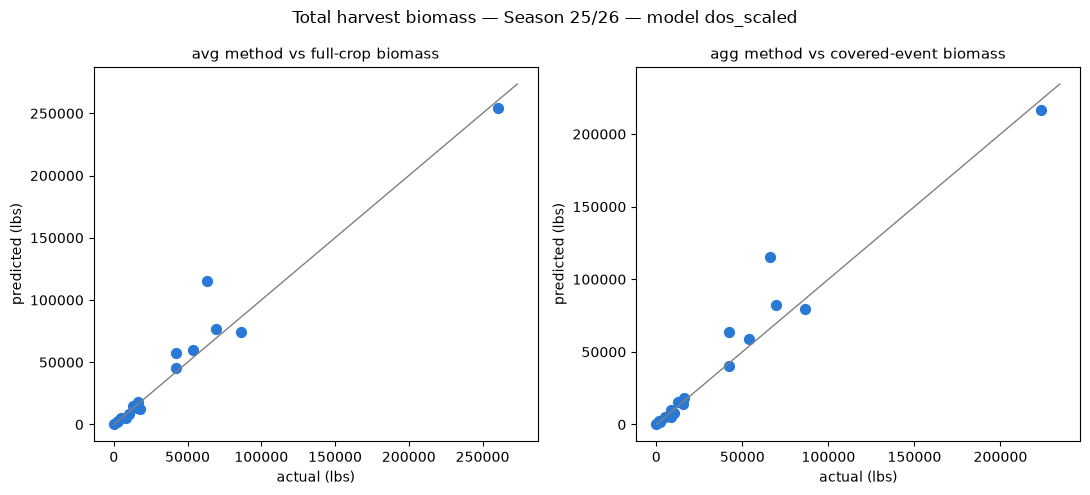

In [105]:
def biomass_table(pipe=None, events_df=None, use_last_obs=False):
    """Per-crop total harvested biomass, actual vs predicted, for one pipeline.

    avg method: mean(calibrated lbs/ft over predicted events) x harvest_line_ft_group,
                scored against the crop's full true_biomass_lbs.
    agg method: sum(calibrated lbs/ft_i x event_line_ft_i), scored against the biomass of
                the covered events only (actual lbs/ft_i x line_i; same-day multi-harvest
                day-averaging makes this a close approximation of the logged weights).
    use_last_obs=True swaps the model's predictions for the OLD method (most recent
    sample/partial harvest carried forward, as-is) so the same table scores the benchmark.
    """
    pipe = pipe or HARVEST_PIPE
    events_df = pipe["test_events"] if events_df is None else events_df
    rows = []
    for (farm, season, spec), g in events_df.groupby(["Farm Name", "Season", "Species"]):
        if use_last_obs:
            preds = g["last_obs_lbs_ft"].values.astype(float)
        else:
            preds = np.array([
                calibrate(weighted_pred(r, w_expdecay, pipe["tau"]), pipe=pipe)
                for _, r in g.iterrows()
            ])
        line_i = g["event_line_ft"].values.astype(float)
        actual_i = g["actual_lbs_ft"].values.astype(float)
        harvest_line = float(g["harvest_line_ft_group"].iloc[0])
        actual_total = float(g["true_biomass_lbs_group"].iloc[0])
        actual_covered = float(np.sum(actual_i * line_i))
        pred_avg_total = float(preds.mean() * harvest_line)
        pred_agg_total = float(np.sum(preds * line_i))
        rows.append({
            "Farm Name": farm, "Season": season,
            "n_pred_events": len(g),
            "harvest_line_ft": harvest_line,
            "covered_line_ft": float(line_i.sum()),
            "actual_total_lbs": actual_total,
            "pred_total_avg_lbs": pred_avg_total,
            "pct_err_avg": (pred_avg_total - actual_total) / actual_total * 100
                           if actual_total > 0 else np.nan,
            "actual_covered_lbs": actual_covered,
            "pred_total_agg_lbs": pred_agg_total,
            "pct_err_agg": (pred_agg_total - actual_covered) / actual_covered * 100
                           if actual_covered > 0 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("Farm Name").reset_index(drop=True)


def with_total_row(bm):
    """Append a season-level TOTAL row: summed line and biomass, with % errors
    recomputed on the sums (portfolio-level error — per-crop misses can cancel)."""
    if bm.empty:
        return bm
    s = bm.sum(numeric_only=True)
    tot = {
        "Farm Name": "TOTAL", "Season": "",
        "n_pred_events": int(s["n_pred_events"]),
        "harvest_line_ft": s["harvest_line_ft"],
        "covered_line_ft": s["covered_line_ft"],
        "actual_total_lbs": s["actual_total_lbs"],
        "pred_total_avg_lbs": s["pred_total_avg_lbs"],
        "pct_err_avg": (s["pred_total_avg_lbs"] - s["actual_total_lbs"])
                       / s["actual_total_lbs"] * 100 if s["actual_total_lbs"] > 0 else np.nan,
        "actual_covered_lbs": s["actual_covered_lbs"],
        "pred_total_agg_lbs": s["pred_total_agg_lbs"],
        "pct_err_agg": (s["pred_total_agg_lbs"] - s["actual_covered_lbs"])
                       / s["actual_covered_lbs"] * 100 if s["actual_covered_lbs"] > 0 else np.nan,
    }
    return pd.concat([bm, pd.DataFrame([tot])], ignore_index=True)


bm = biomass_table()
print(f"--- {TEST_SEASON} total biomass, model {HARVEST_MODEL}, cal {CAL_MODE} ---")
display(with_total_row(bm).round(1))
for col, name in [("pct_err_avg", "avg lbs/ft x harvested line (vs full crop)"),
                  ("pct_err_agg", "per-event lbs/ft x event line (vs covered events)")]:
    e = bm[col].dropna()
    print(f"{name:52s} median |%err| = {e.abs().median():5.1f}%   "
          f"median %err = {e.median():+5.1f}%   n={len(e)}")

# same summary across every pipeline (per-crop median + season-total portfolio error)
print("\nby pipeline — median per-crop |%err| and season-TOTAL %err:")
for k, p in PIPELINES.items():
    b = biomass_table(p)
    if len(b):
        t = with_total_row(b).iloc[-1]
        print(f"  {k:12s} avg: med|%err| {b['pct_err_avg'].abs().median():5.1f}%, "
              f"TOTAL {t['pct_err_avg']:+5.1f}%   "
              f"agg: med|%err| {b['pct_err_agg'].abs().median():5.1f}%, "
              f"TOTAL {t['pct_err_agg']:+5.1f}%")
b_old = biomass_table(use_last_obs=True)
if len(b_old):
    t = with_total_row(b_old).iloc[-1]
    print(f"  {'OLD last-obs':12s} avg: med|%err| {b_old['pct_err_avg'].abs().median():5.1f}%, "
          f"TOTAL {t['pct_err_avg']:+5.1f}%   "
          f"agg: med|%err| {b_old['pct_err_agg'].abs().median():5.1f}%, "
          f"TOTAL {t['pct_err_agg']:+5.1f}%")

# scatter: each method against its own target
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (xcol, ycol, ttl) in zip(axes, [
    ("actual_total_lbs", "pred_total_avg_lbs", "avg method vs full-crop biomass"),
    ("actual_covered_lbs", "pred_total_agg_lbs", "agg method vs covered-event biomass"),
]):
    ax.scatter(bm[xcol], bm[ycol], s=50, color="#2a78d6")
    lim = max(bm[xcol].max(), bm[ycol].max()) * 1.05
    ax.plot([0, lim], [0, lim], color="gray", lw=1)
    ax.set_xlabel("actual (lbs)")
    ax.set_ylabel("predicted (lbs)")
    ax.set_title(ttl, fontsize=11)
plt.suptitle(f"Total harvest biomass — {TEST_SEASON} — model {HARVEST_MODEL}", fontsize=12)
plt.tight_layout()
plt.show()

### 6.5c GreenWave method vs this model

Two numbers on the held-out season:

1. Per-harvest MAE (lbs/ft): last-observation baseline vs model.
2. Total-biomass error: which method gets closer to the actual total.


Held-out season: Season 25/26   |   75 harvest events across 17 crops


,method,per-harvest MAE (lbs/ft),per-harvest bias (lbs/ft),median pred/actual,per-crop biomass MAE (lbs),median |% err| biomass,season-total % err
0,GreenWave — last observation carried forward,1.04,-0.05,0.99,5565.20,17.39,9.06
1,"This model — dos_scaled, calibrated",0.89,-0.06,0.98,6764.89,16.28,10.74



per-harvest lbs/ft MAE reduction: 14%   |   per-crop biomass MAE reduction: -22%


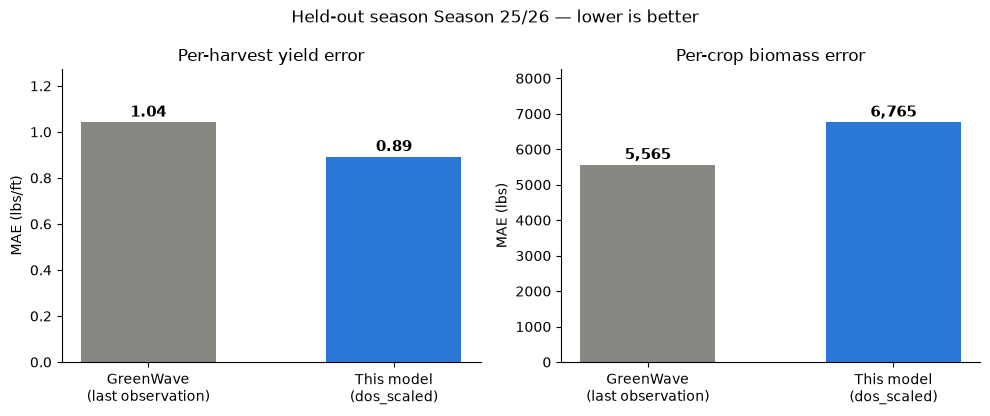

In [116]:
REPORT_PIPE = PIPELINES["dos_scaled"]

# ---- 1. per-harvest lbs/ft, identical held-out events ----
_te = REPORT_PIPE["test_events"]
_actual = _te["actual_lbs_ft"].values
_gw = _te["last_obs_lbs_ft"].values
_ours = REPORT_PIPE["coeff_all"] * all_weighted_preds(_te, w_expdecay, REPORT_PIPE["tau"])

# ---- 2. per-crop biomass (aggregate per-event x line, vs covered logged weight) ----
_b_gw = biomass_table(REPORT_PIPE, use_last_obs=True)
_b_us = biomass_table(REPORT_PIPE)


def _report_row(label, pred, actual, b):
    ok = np.isfinite(pred)
    err = pred[ok] - actual[ok]
    berr = b["pred_total_agg_lbs"] - b["actual_covered_lbs"]
    tot = with_total_row(b).iloc[-1]
    return {
        "method": label,
        "per-harvest MAE (lbs/ft)": float(np.abs(err).mean()),
        "per-harvest bias (lbs/ft)": float(err.mean()),
        "median pred/actual": float(np.median(pred[ok] / actual[ok])),
        "per-crop biomass MAE (lbs)": float(berr.abs().mean()),
        "median |% err| biomass": float(b["pct_err_agg"].abs().median()),
        "season-total % err": float(tot["pct_err_agg"]),
    }


report = pd.DataFrame([
    _report_row("GreenWave — last observation carried forward", _gw, _actual, _b_gw),
    _report_row("This model — dos_scaled, calibrated", _ours, _actual, _b_us),
])
print(f"Held-out season: {TEST_SEASON}   |   "
      f"{len(_te)} harvest events across {len(_b_us)} crops")
display(report.round(2))

_imp_ft = (1 - report.iloc[1, 1] / report.iloc[0, 1]) * 100
_imp_bm = (1 - report.loc[1, "per-crop biomass MAE (lbs)"]
           / report.loc[0, "per-crop biomass MAE (lbs)"]) * 100
print(f"\nper-harvest lbs/ft MAE reduction: {_imp_ft:.0f}%   |   "
      f"per-crop biomass MAE reduction: {_imp_bm:.0f}%")

# ---- the one-figure version ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
labels = ["GreenWave\n(last observation)", "This model\n(dos_scaled)"]
colors = ["#898781", "#2a78d6"]
for ax, col, ttl, unit in zip(
    axes,
    ["per-harvest MAE (lbs/ft)", "per-crop biomass MAE (lbs)"],
    ["Per-harvest yield error", "Per-crop biomass error"],
    ["MAE (lbs/ft)", "MAE (lbs)"],
):
    vals = report[col].values
    bars = ax.bar(labels, vals, color=colors, width=0.55)
    for b_, v in zip(bars, vals):
        ax.annotate(f"{v:,.2f}" if v < 100 else f"{v:,.0f}",
                    xy=(b_.get_x() + b_.get_width() / 2, v),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=11, fontweight="bold")
    ax.set_title(ttl, fontsize=12)
    ax.set_ylabel(unit)
    ax.set_ylim(0, max(vals) * 1.22)
    for s_ in ["top", "right"]:
        ax.spines[s_].set_visible(False)
plt.suptitle(f"Held-out season {TEST_SEASON} — lower is better", fontsize=12)
plt.tight_layout()
plt.show()

### 6.6 Diagnostics for the working pipeline


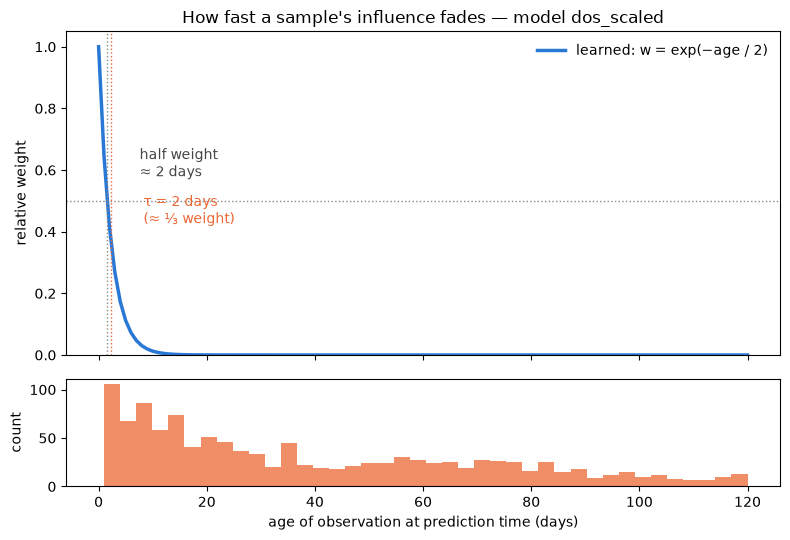

weight at   7 days: 0.05
weight at  14 days: 0.00
weight at  30 days: 0.00
weight at  60 days: 0.00

tau (dos): 20.8 days
tau (dos_region): 22.6 days
tau (dos_scaled): 2.3 days


In [107]:
# ---- visualize the learned exponential weights (working pipeline) ----
TAU = HARVEST_PIPE["tau"]
gap_grid = np.arange(0, 121)
w_grid = np.exp(-gap_grid / TAU)

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(8, 5.5), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax.plot(gap_grid, w_grid, lw=2.5, color="#2a78d6",
        label=f"learned: w = exp(−age / {TAU:.0f})")

half_d = 0.693 * TAU
ax.axhline(0.5, ls=":", color="#898781", lw=1)
ax.axvline(half_d, ls=":", color="#898781", lw=1)
ax.annotate(f"half weight\n≈ {half_d:.0f} days", xy=(half_d, 0.5),
            xytext=(half_d + 6, 0.58), fontsize=10, color="#444444")
ax.axvline(TAU, ls=":", color="#eb6834", lw=1)
ax.annotate(f"τ = {TAU:.0f} days\n(≈ ⅓ weight)", xy=(TAU, np.exp(-1)),
            xytext=(TAU + 6, np.exp(-1) + 0.06), fontsize=10, color="#eb6834")

ax.set_ylabel("relative weight")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=10)
ax.set_title(f"How fast a sample's influence fades — model {HARVEST_MODEL}")

all_gaps = np.concatenate(HARVEST_PIPE["train_events"]["gaps"].values)
ax2.hist(all_gaps[all_gaps <= 120], bins=40, color="#eb6834", alpha=0.75)
ax2.set_xlabel("age of observation at prediction time (days)")
ax2.set_ylabel("count")

plt.tight_layout()
plt.show()

for d in (7, 14, 30, 60):
    print(f"weight at {d:3d} days: {np.exp(-d / TAU):.2f}")

# per-model tau side by side — do the region curves change how fast samples go stale?
print()
for k, p in PIPELINES.items():
    print(f"tau ({k}): {p['tau']:.1f} days")

median ratio (actual / weighted projection) by event class — model dos_scaled:


,median,mean,std,count
event_class,,,,
final harvest (incomplete line),0.537,0.531,0.190,4
final harvest (total),0.907,0.934,0.658,34
partial (earlier) harvest,0.995,1.112,0.696,134
single harvest,0.716,0.777,0.492,34


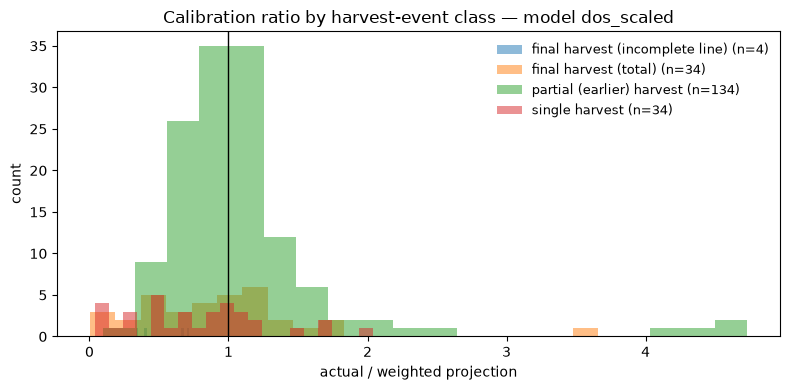

In [108]:
# ---- median ratio by harvest-event class (working pipeline) ----
tr = HARVEST_PIPE["train_events"].copy()
tr["weighted_pred"] = HARVEST_PIPE["wp_train"]
tr["ratio"] = tr["actual_lbs_ft"] / tr["weighted_pred"]

tr["event_class"] = np.select(
    [
        (tr["n_harvests_in_group"] == 1),
        (tr["is_final_harvest"]) & (tr["group_is_total_harvest"]),
        (~tr["is_final_harvest"]),
    ],
    ["single harvest", "final harvest (total)", "partial (earlier) harvest"],
    default="final harvest (incomplete line)",
)

print(f"median ratio (actual / weighted projection) by event class — model {HARVEST_MODEL}:")
display(
    tr.groupby("event_class")["ratio"]
    .agg(["median", "mean", "std", "count"])
    .round(3)
)

fig, ax = plt.subplots(figsize=(8, 4))
for cls, sub in tr.groupby("event_class"):
    ax.hist(sub["ratio"], bins=20, alpha=0.5, label=f"{cls} (n={len(sub)})")
ax.axvline(1.0, color="black", lw=1)
ax.set_xlabel("actual / weighted projection")
ax.set_ylabel("count")
ax.set_title(f"Calibration ratio by harvest-event class — model {HARVEST_MODEL}")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

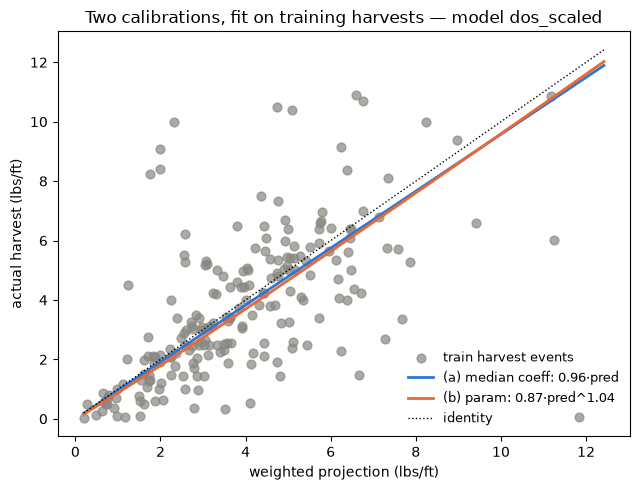

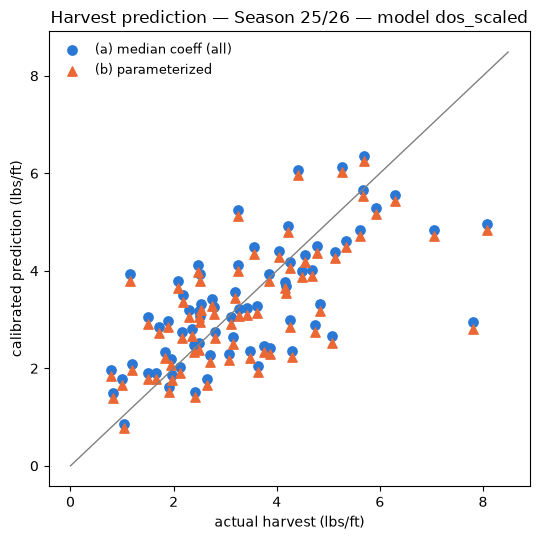

In [109]:
# ---- the two calibrations across the prediction range (working pipeline) ----
wp_train = HARVEST_PIPE["wp_train"]
pc = HARVEST_PIPE["param_cal"]
p_grid = np.linspace(max(wp_train.min(), 0.1), wp_train.max() * 1.05, 100)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(wp_train, HARVEST_PIPE["train_events"]["actual_lbs_ft"], s=40,
           color="#898781", alpha=0.7, label="train harvest events")
ax.plot(p_grid, HARVEST_PIPE["coeff_all"] * p_grid, color="#2a78d6", lw=2,
        label=f"(a) median coeff: {HARVEST_PIPE['coeff_all']:.2f}·pred")
ax.plot(p_grid, pc["apply"](p_grid), color="#eb6834", lw=2,
        label=f"(b) param: {np.exp(pc['alpha']):.2f}·pred^{pc['beta']:.2f}")
ax.plot(p_grid, p_grid, color="black", lw=1, ls=":", label="identity")
ax.set_xlabel("weighted projection (lbs/ft)")
ax.set_ylabel("actual harvest (lbs/ft)")
ax.set_title(f"Two calibrations, fit on training harvests — model {HARVEST_MODEL}")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# held-out scatter, both calibrations, working pipeline
te = HARVEST_PIPE["test_events"]
if len(te):
    wp_test = all_weighted_preds(te, w_expdecay, HARVEST_PIPE["tau"])
    actual = te["actual_lbs_ft"].values
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(actual, HARVEST_PIPE["coeff_all"] * wp_test, s=45, color="#2a78d6",
               label="(a) median coeff (all)")
    ax.scatter(actual, pc["apply"](wp_test), s=45, color="#eb6834",
               marker="^", label="(b) parameterized")
    lim = max(actual.max(), (HARVEST_PIPE["coeff_all"] * wp_test).max(),
              pc["apply"](wp_test).max()) * 1.05
    ax.plot([0, lim], [0, lim], color="gray", lw=1)
    ax.set_xlabel("actual harvest (lbs/ft)")
    ax.set_ylabel("calibrated prediction (lbs/ft)")
    ax.set_title(f"Harvest prediction — {TEST_SEASON} — model {HARVEST_MODEL}")
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

### 6.7 Deployment

Predict the harvest for any group from its samples so far. Pass `pipe=PIPELINES["dos_region"]` to use the region-curve model.


/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2401855014.py:31: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_date = season_oct1 + pd.Timedelta(days=TYPICAL_HARVEST_DOS)


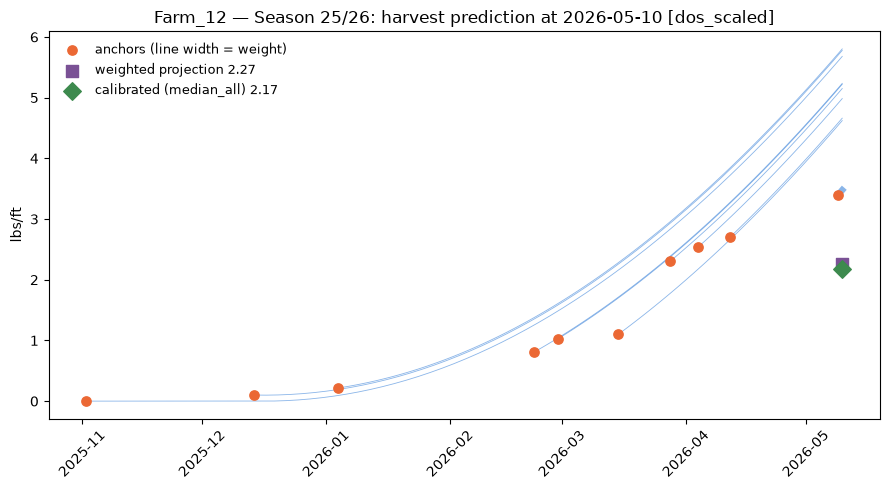

/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2401855014.py:31: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_date = season_oct1 + pd.Timedelta(days=TYPICAL_HARVEST_DOS)


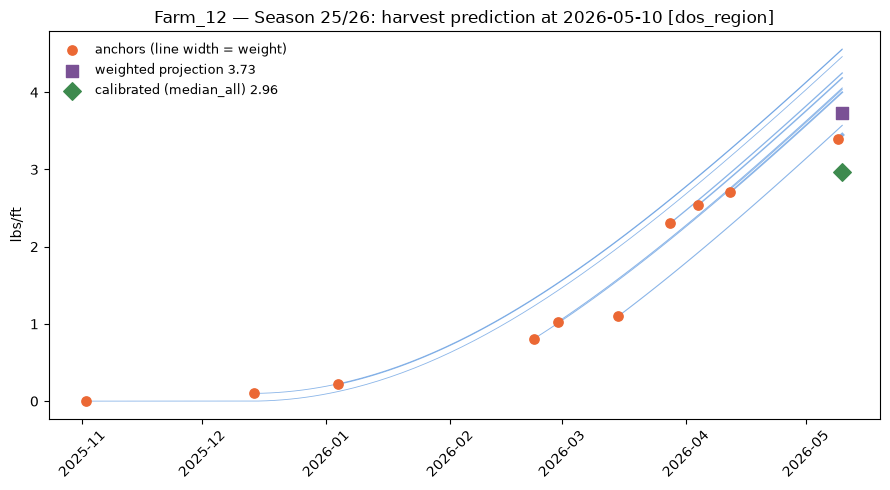

,model_key,target_date,weighted_pred_lbs_ft,calibrated_pred_lbs_ft,cal_mode,available_line_ft,implied_total_biomass_lbs,n_anchors
0,dos_scaled,2026-05-10,2.265797,2.169678,median_all,3000.0,6509.032704,10
1,dos_region,2026-05-10,3.725917,2.964139,median_all,3000.0,8892.418194,10


In [110]:
# median day-of-season of training harvests = default target date if none given
_train_harvest_dos = HARVEST_PIPE["train_events"]["harvest_date"].apply(day_of_season)
TYPICAL_HARVEST_DOS = int(_train_harvest_dos.median()) if len(_train_harvest_dos) else 200


def predict_harvest(farm, season, species=MODEL_SPECIES, target_date=None,
                    pipe=None, plot=True):
    """Weighted, calibrated harvest-yield prediction (lbs/ft) for one group.

    Uses every observation available for the group (outplant anchor, samples,
    partial harvests), projects each to target_date with the pipeline's rate model,
    combines with the pipeline's learned weights, applies the chosen calibration.
    Multiply by the group's available_line_ft for a total-biomass (lbs) estimate.
    """
    pipe = pipe or HARVEST_PIPE
    model_key = pipe["model_key"]
    g = cal_obs[
        (cal_obs["Farm Name"] == farm)
        & (cal_obs["Season"] == season)
        & (cal_obs["Species"] == species)
    ].sort_values("Log Date")
    if g.empty:
        raise ValueError("no observations for this group after filtering")
    gi = grp_lookup.loc[(farm, season, species)]
    rid = g["region_id"].iloc[0]
    seed = g["seed_date"].iloc[0]

    if target_date is None:
        season_oct1 = pd.Timestamp(year=seed.year if seed.month >= 10 else seed.year - 1,
                                   month=10, day=1)
        target_date = season_oct1 + pd.Timedelta(days=TYPICAL_HARVEST_DOS)
    target_date = pd.Timestamp(target_date)

    anchors = g[g["Log Date"] < target_date]
    if anchors.empty:
        raise ValueError("no anchors before the target date")
    hdiv = pipe.get("harvest_anchor_div", 1.0)
    pmult = pipe.get("pred_mult", 1.0)
    gaps = (target_date - anchors["Log Date"]).dt.days.values.astype(float)
    curves, preds = [], []   # curves/preds are in the pipeline's MODEL scale (sample scale)
    for (_, a), gap in zip(anchors.iterrows(), gaps):
        a_val = a["lbs_ft"] / hdiv if a["is_harvest"] else a["lbs_ft"]
        c = project(model_key, a["Log Date"], a_val, target_date, rid)
        curves.append(c)
        preds.append(float(c.iloc[-1]))
    w = w_expdecay(gaps, pipe["tau"])
    w = w / w.sum()
    weighted = pmult * float(np.sum(w * np.array(preds)))   # back to harvest scale
    calibrated = calibrate(weighted, pipe=pipe)

    result = {
        "model_key": model_key,
        "target_date": target_date,
        "weighted_pred_lbs_ft": weighted,
        "calibrated_pred_lbs_ft": calibrated,
        "cal_mode": CAL_MODE,
        "available_line_ft": float(gi["available_line_ft"]),
        "implied_total_biomass_lbs": calibrated * float(gi["available_line_ft"]),
        "n_anchors": len(preds),
        "anchor_weights": pd.DataFrame(
            {"anchor_date": anchors["Log Date"].values, "anchor_lbs_ft": anchors["lbs_ft"].values,
             "gap_days": gaps, "weight": w, "projected_lbs_ft": preds}
        ),
    }

    if plot:
        fig, ax = plt.subplots(figsize=(9, 5))
        for c, wi in zip(curves, w):
            ax.plot(c.index, c.values, color="#2a78d6", lw=0.6 + 4 * wi, alpha=0.55)
        ax.scatter(anchors["Log Date"], anchors["lbs_ft"], color="#eb6834", s=45,
                   zorder=5, label="anchors (line width = weight)")
        ax.scatter([target_date], [weighted], color="#7a5195", marker="s", s=80,
                   zorder=6, label=f"weighted projection {weighted:.2f}")
        ax.scatter([target_date], [calibrated], color="#3d8a4e", marker="D", s=80,
                   zorder=6, label=f"calibrated ({CAL_MODE}) {calibrated:.2f}")
        ax.set_title(f"{farm} — {season}: harvest prediction at {target_date.date()} "
                     f"[{model_key}]")
        ax.set_ylabel("lbs/ft")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=9, frameon=False)
        plt.tight_layout()
        plt.show()
    return result


# example on a test-season group, working pipeline vs region curves side by side
res = predict_harvest(test_farms[0], TEST_SEASON)
res_region = predict_harvest(test_farms[0], TEST_SEASON, pipe=PIPELINES["dos_region"])
pd.DataFrame([
    {k: v for k, v in r.items() if k != "anchor_weights"}
    for r in (res, res_region)
])

### 6.8 Rolling harvest forecast

What the model would have said on each day of the season.


/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2439494988.py:27: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  season_end = season_oct1 + pd.Timedelta(days=HORIZON_DAYS + 60)
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2439494988.py:41: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  t0 = anchors["Log Date"].min() + pd.Timedelta(days=step_days)
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_14460/2439494988.py:27: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a speci

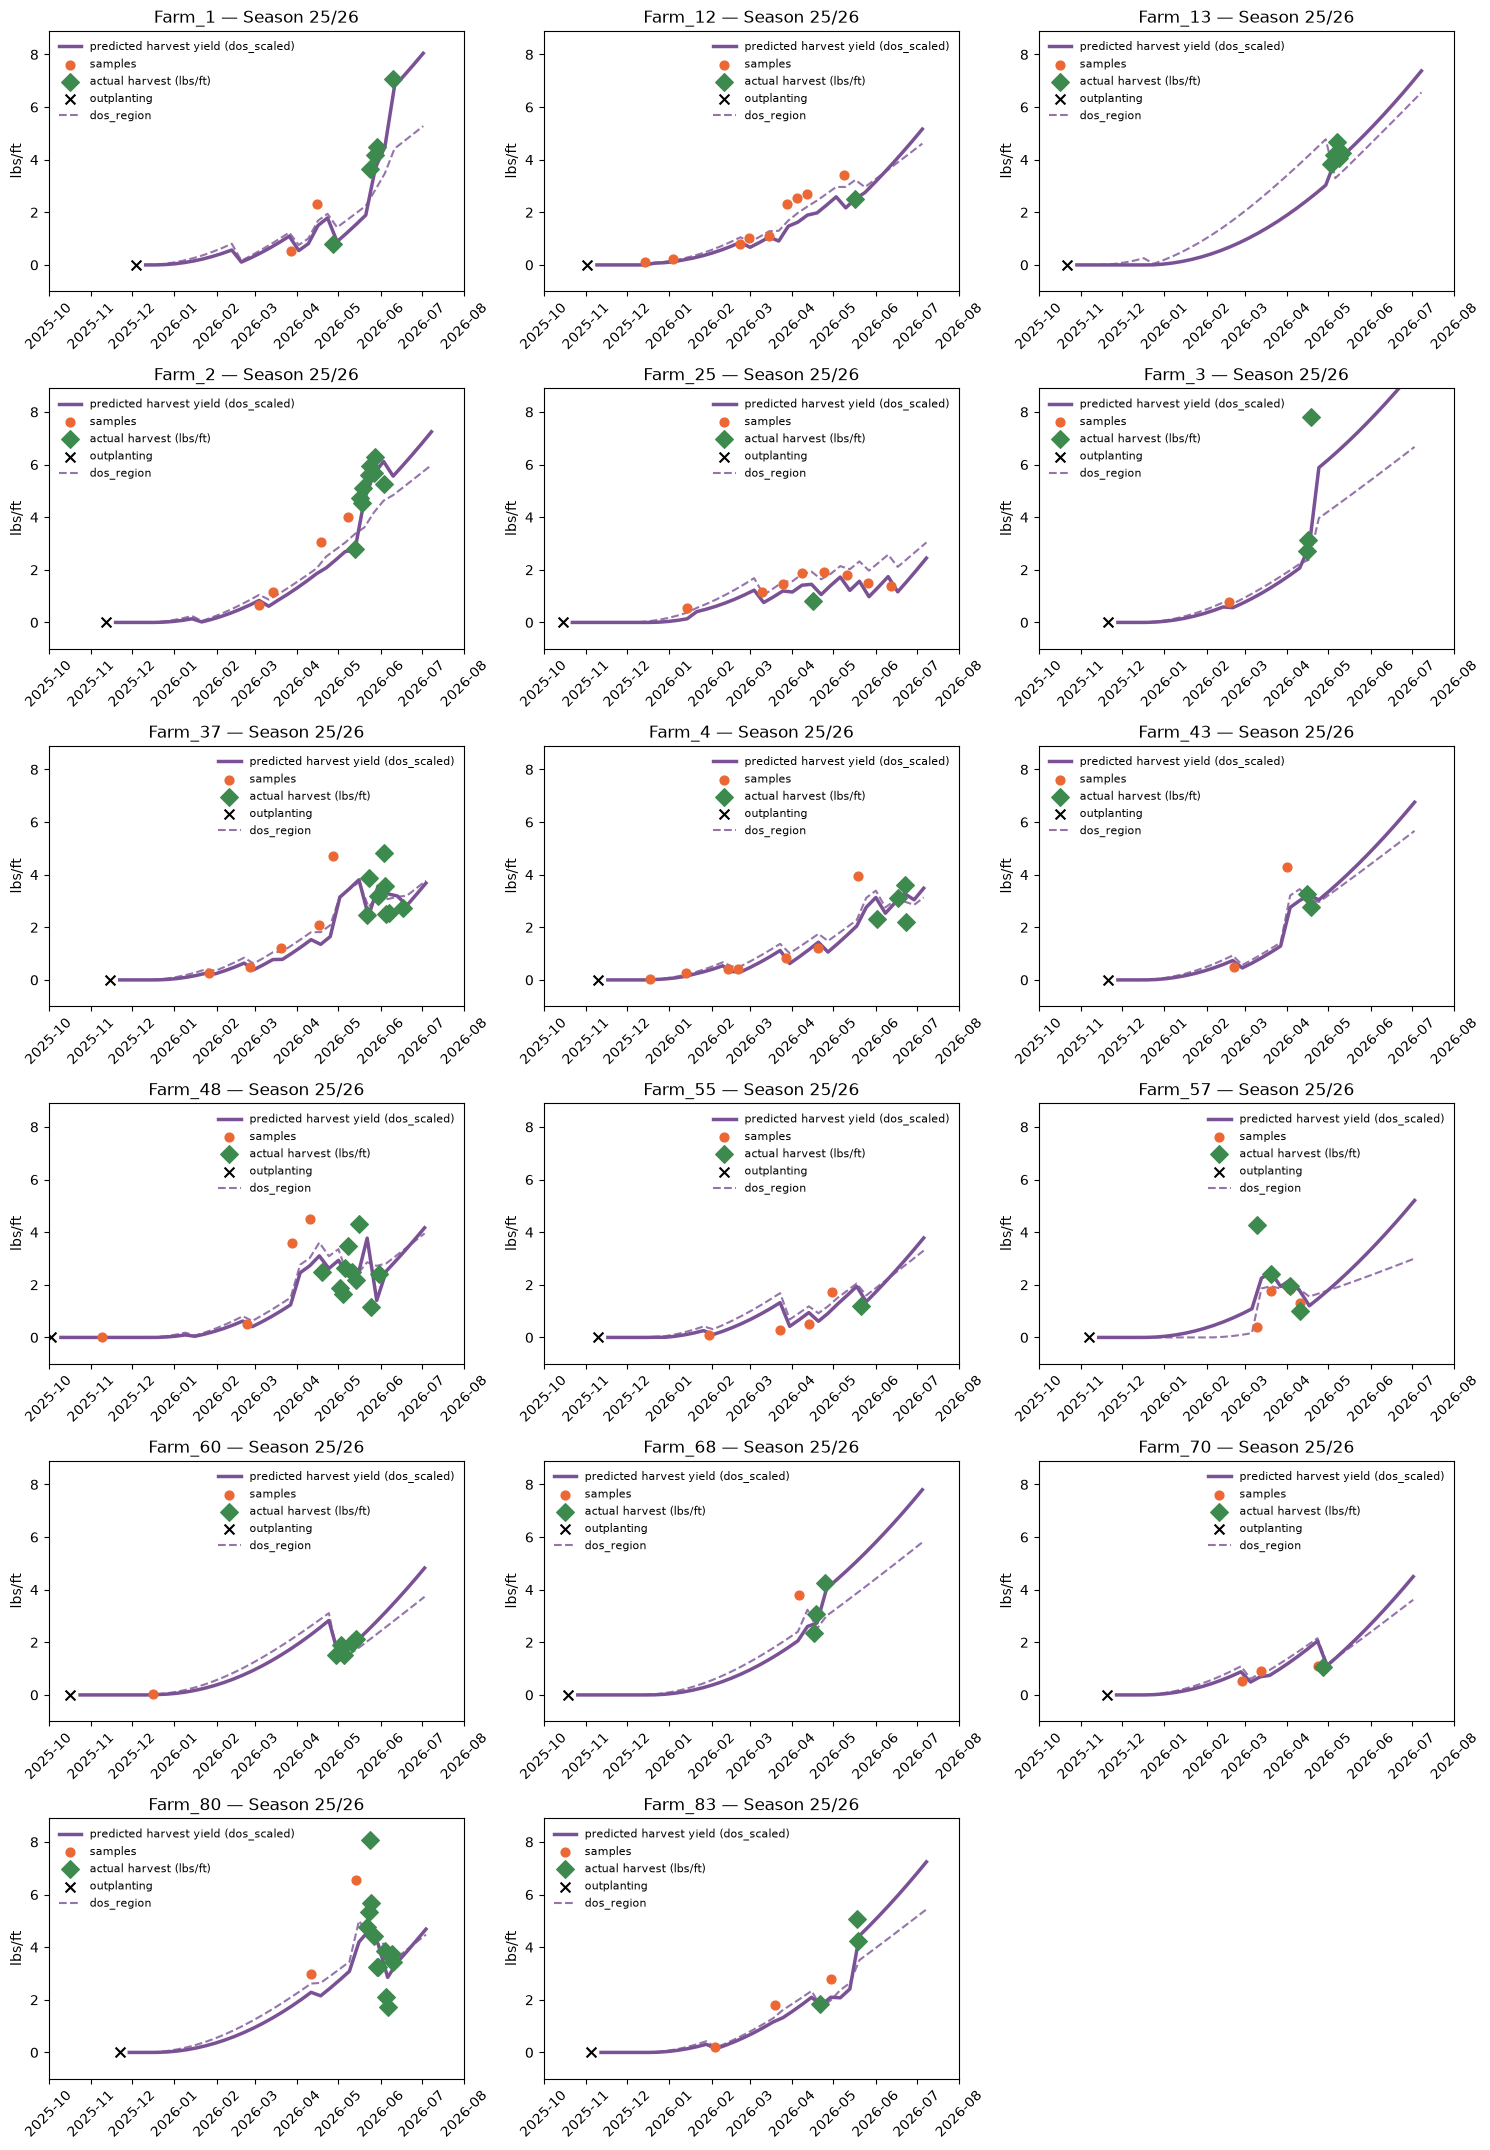

In [111]:
def predict_harvest_trajectory(farm, season, species=MODEL_SPECIES, pipe=None,
                               step_days=7, ax=None, show=True):
    """Rolling harvest-yield forecast through the season.

    For each candidate date t (weekly grid from first observation to season end), use ONLY
    the anchors logged before t, project each forward to t with the pipeline's rate model,
    combine with its learned weights (gaps recomputed against t), and apply the chosen
    calibration. This is the forecast a farmer would have seen on day t. Actual samples
    and harvests are overlaid.
    """
    pipe = pipe or HARVEST_PIPE
    model_key = pipe["model_key"]

    g = cal_obs[
        (cal_obs["Farm Name"] == farm)
        & (cal_obs["Season"] == season)
        & (cal_obs["Species"] == species)
    ].sort_values("Log Date")
    if g.empty:
        raise ValueError(f"{farm} / {season} / {species}: no observations after filtering")
    rid = g["region_id"].iloc[0]
    seed = g["seed_date"].iloc[0]

    season_oct1 = pd.Timestamp(
        year=seed.year if seed.month >= 10 else seed.year - 1, month=10, day=1
    )
    season_end = season_oct1 + pd.Timedelta(days=HORIZON_DAYS + 60)

    # project every anchor ONCE out to season end; read intermediate dates off the curve
    # (prior-harvest anchors converted to the model's sample scale first, if the pipe scales)
    hdiv = pipe.get("harvest_anchor_div", 1.0)
    pmult = pipe.get("pred_mult", 1.0)
    anchors = g.reset_index(drop=True)
    curves = [
        project(model_key, a["Log Date"],
                a["lbs_ft"] / hdiv if a["is_harvest"] else a["lbs_ft"],
                season_end, rid)
        for _, a in anchors.iterrows()
    ]

    t0 = anchors["Log Date"].min() + pd.Timedelta(days=step_days)
    grid = pd.date_range(t0, season_end, freq=f"{step_days}D")
    rows = []
    for t in grid:
        avail = [
            (a["Log Date"], c)
            for (_, a), c in zip(anchors.iterrows(), curves)
            if a["Log Date"] < t
        ]
        if not avail:
            continue
        gaps = np.array([(t - d).days for d, _ in avail], dtype=float)
        preds = np.array([float(c.loc[t]) for _, c in avail])
        w = w_expdecay(gaps, pipe["tau"])
        w = w / w.sum()
        rows.append({
            "date": t,
            "pred_lbs_ft": calibrate(pmult * float(np.sum(w * preds)), pipe=pipe),
            "n_anchors": len(preds),
        })
    traj = pd.DataFrame(rows).set_index("date")

    if show:
        if ax is None:
            fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(traj.index, traj["pred_lbs_ft"], color="#7a5195", lw=2.5,
                label=f"predicted harvest yield ({model_key})")
        samp = g[(~g["is_outplant"]) & (~g["is_harvest"])]
        ax.scatter(samp["Log Date"], samp["lbs_ft"], color="#eb6834", s=40,
                   zorder=5, label="samples")
        harv = g[g["is_harvest"]]
        if len(harv):
            ax.scatter(harv["Log Date"], harv["lbs_ft"], color="#3d8a4e", marker="D",
                       s=80, zorder=6, label="actual harvest (lbs/ft)")
        ax.scatter([seed], [0], color="black", marker="x", s=50, zorder=6,
                   label="outplanting")
        ax.set_title(f"{farm} — {season}")
        ax.set_ylabel("lbs/ft")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=8, frameon=False)
    return traj


# shared axes across all panels
X_MIN = pd.Timestamp("2025-10-01")           # season start
X_MAX = pd.Timestamp("2026-08-01")
Y_MAX = (cal_obs[(cal_obs["Season"] == TEST_SEASON) & (~cal_obs["is_outplant"])]
         ["lbs_ft"].max() * 1.1)             # headroom over the biggest observation


# one panel per test-season group that actually harvested — working pipeline solid,
# region-curve pipeline dashed on the same axes for a direct visual comparison
_hg = sorted(
    cal_obs[(cal_obs["Season"] == TEST_SEASON) & (cal_obs["is_harvest"])]["Farm Name"].unique()
)
ncol = 3
nrow = int(np.ceil(len(_hg) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.6 * nrow), squeeze=False)
for ax in axes.flat[len(_hg):]:
    ax.axis("off")
for farm, ax in zip(_hg, axes.flat):
    try:
        predict_harvest_trajectory(farm, TEST_SEASON, ax=ax)
        if HARVEST_MODEL != "dos_region":
            traj_r = predict_harvest_trajectory(farm, TEST_SEASON,
                                                pipe=PIPELINES["dos_region"], show=False)
            ax.plot(traj_r.index, traj_r["pred_lbs_ft"], color="#7a5195", lw=1.5,
                    ls="--", alpha=0.8, label="dos_region")
            ax.legend(fontsize=8, frameon=False)
    except Exception as e:
        ax.set_title(f"{farm}: {type(e).__name__}")
        ax.axis("off")
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(-1, Y_MAX)
plt.tight_layout()
plt.show()

### 6.9 OLD method: last observation carried forward

The benchmark. Also appears as `OLD: last obs` in 6.3 and `pred_last_obs` in Table 2.


In [112]:
# OLD method, test season, per-foot: last obs (sample or partial harvest) vs each harvest
rows = []
test_cals = cal_obs[cal_obs["Season"] == TEST_SEASON]
for key, g in test_cals.groupby(GROUP):
    for _, h in g[g["is_harvest"]].iterrows():
        lo = last_obs_lbs_ft(g, h["Log Date"])
        if np.isfinite(lo):
            rows.append({"actual": h["lbs_ft"], "naive": lo})
nv = pd.DataFrame(rows)
nv["err"] = nv["naive"] - nv["actual"]
print(f"per-foot: n={len(nv)}  MAE {nv['err'].abs().mean():.2f}  bias {nv['err'].mean():+.2f}")

# biomass version: last sample x (outplanted - lost) line vs true harvested weight
gi = group_info[(group_info["Species"] == MODEL_SPECIES) & group_info["flag_has_harvest"]
                & (group_info["Season"] == TEST_SEASON)]
last_samp = (cal_obs[~cal_obs["is_harvest"] & ~cal_obs["is_outplant"]]
             .groupby(GROUP).tail(1)[GROUP + ["lbs_ft"]])
gi = gi.merge(last_samp, on=GROUP)
ratio = (gi["lbs_ft"] * gi["available_line_ft"]) / gi["true_biomass_lbs"]
print(f"biomass: n={len(gi)}  median naive/actual {ratio.median():.2f}x  "
      f"median abs % error {abs(ratio - 1).median():.0%}")

per-foot: n=75  MAE 1.04  bias -0.05
biomass: n=16  median naive/actual 1.32x  median abs % error 70%


### 6.10 Lookups and raw-event diagnostics


In [113]:
def list_samples(ev=None, farm=None, season=None, species=None):
    """All non-harvest data points (outplant + sample). Defaults to the master events table."""
    ev = events if ev is None else ev
    ev = ev[~ev["is_harvest"].fillna(False).astype(bool)]
    if farm is not None:
        ev = ev[ev["Farm Name"] == farm]
    if season is not None:
        ev = ev[ev["Season"] == season]
    if species is not None:
        ev = ev[ev["Species"] == species]
    cols = ["Farm Name", "Season", "Species", "Log Date", "dos", "lbs_ft"]
    return (ev[cols].sort_values(["Farm Name", "Season", "Log Date"])
            .reset_index(drop=True))


def list_harvests(ev=None, farm=None, season=None, species=None):
    """All harvest data points, optionally filtered — the lookup for choosing what to plot."""
    ev = events if ev is None else ev
    ev = ev[ev["is_harvest"].fillna(False).astype(bool)]
    if farm is not None:
        ev = ev[ev["Farm Name"] == farm]
    if season is not None:
        ev = ev[ev["Season"] == season]
    if species is not None:
        ev = ev[ev["Species"] == species]
    cols = ["Farm Name", "Season", "Species", "Log Date", "dos", "lbs_ft"]
    return (ev[cols].sort_values(["Farm Name", "Season", "Log Date"])
            .reset_index(drop=True))


BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#3d8a4e"


def plot_crop_events(farm, season, species=MODEL_SPECIES, ax=None):
    """One crop's raw logged events: outplanting (X), samples (dots), harvests (diamonds)."""
    g = events[
        (events["Farm Name"] == farm)
        & (events["Season"] == season)
        & (events["Species"] == species)
    ].sort_values("Log Date")
    if g.empty:
        raise ValueError(f"{farm} / {season} / {species}: no events")
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 4.5), dpi=150)

    op = g[g["is_outplant"]]
    samp = g[(~g["is_outplant"]) & (~g["is_harvest"])]
    harv = g[g["is_harvest"]]

    ax.scatter(samp["Log Date"], samp["lbs_ft"], color=ORANGE, s=70, zorder=5,
               edgecolor="white", lw=1, label=f"samples (n={len(samp)})")
    ax.scatter(harv["Log Date"], harv["lbs_ft"], color=GREEN, marker="D", s=110,
               zorder=6, edgecolor="white", lw=1, label=f"harvest (n={len(harv)})")
    ax.scatter(op["Log Date"], op["lbs_ft"], color="black", marker="X", s=160,
               zorder=6, label="outplanting (yield = 0)")

    ax.set_title(f"{farm} — {season} — {species}", fontsize=12)
    ax.set_ylabel("yield (lbs/ft)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(frameon=False, fontsize=10)
    for s_ in ["top", "right"]:
        ax.spines[s_].set_visible(False)
    plt.tight_layout()
    return ax

### 6.11 Season replay

For one farm-season-species, show the model's story as logs come in: outplanting, each sample (predicted vs actual), each harvest (predicted vs actual). Sorted by date.


In [114]:
def simulate_season(farm, season, species=MODEL_SPECIES, pipe=None):
    """Chronological replay of one crop: what the model would have said at every logged event.

    Returns one row per event (outplant / sample / harvest) with:
      pred_sample_lbs_ft  — weighted projection from all anchors strictly before the event
                            (0 by construction at outplanting; NaN if nothing predates it)
      pred_harvest_lbs_ft — calibrate(pred_sample) on harvest rows only
      error               — pred_sample − actual on samples, pred_harvest − actual on harvests
      line_ft / actual_lbs / pred_lbs — harvest rows only: the event's harvested line and the
                            actual vs predicted biomass on it; summed in the trailing TOTAL row
    Pass pipe=PIPELINES["dos_region"] (etc.) to replay with a different rate model.
    For scale-fixed pipelines, pred_sample stays in sample scale (comparable to the sample
    rows) and pred_harvest applies ×SCALE then the calibration.
    """
    pipe = pipe or HARVEST_PIPE
    model_key = pipe["model_key"]
    hdiv = pipe.get("harvest_anchor_div", 1.0)
    pmult = pipe.get("pred_mult", 1.0)
    g = cal_obs[
        (cal_obs["Farm Name"] == farm)
        & (cal_obs["Season"] == season)
        & (cal_obs["Species"] == species)
    ].sort_values(["Log Date", "is_harvest"]).reset_index(drop=True)
    if g.empty:
        raise ValueError(f"{farm} / {season} / {species}: no observations after filtering")
    rid = g["region_id"].iloc[0]

    rows = []
    for _, r in g.iterrows():
        if r["is_outplant"]:
            rows.append({
                "date": r["Log Date"].date(), "dos": day_of_season(r["Log Date"]),
                "event": "outplant", "n_anchors": 0,
                "actual_lbs_ft": 0.0, "pred_sample_lbs_ft": 0.0,
                "pred_harvest_lbs_ft": np.nan, "error": 0.0,
            })
            continue

        prior = g[g["Log Date"] < r["Log Date"]]
        gaps = (r["Log Date"] - prior["Log Date"]).dt.days.values.astype(float)
        keep = gaps >= 1
        if keep.any():
            preds = np.array([
                float(project(model_key, a["Log Date"],
                              a["lbs_ft"] / hdiv if a["is_harvest"] else a["lbs_ft"],
                              r["Log Date"], rid).iloc[-1])
                for _, a in prior[keep].iterrows()
            ])
            w = w_expdecay(gaps[keep], pipe["tau"])
            w = w / w.sum()
            pred_sample = float(np.sum(w * preds))   # in SAMPLE scale, comparable to samples
        else:
            pred_sample = np.nan

        is_h = bool(r["is_harvest"])
        pred_harvest = (calibrate(pmult * pred_sample, pipe=pipe)
                        if is_h and np.isfinite(pred_sample) else np.nan)
        scored = pred_harvest if is_h else pred_sample
        line_ft = float(r["event_line_ft"]) if is_h else np.nan
        rows.append({
            "date": r["Log Date"].date(), "dos": day_of_season(r["Log Date"]),
            "event": "harvest" if is_h else "sample", "n_anchors": int(keep.sum()),
            "actual_lbs_ft": r["lbs_ft"], "pred_sample_lbs_ft": pred_sample,
            "pred_harvest_lbs_ft": pred_harvest,
            "error": scored - r["lbs_ft"] if np.isfinite(scored) else np.nan,
            "line_ft": line_ft,
            "actual_lbs": r["lbs_ft"] * line_ft if is_h else np.nan,
            "pred_lbs": pred_harvest * line_ft
                        if is_h and np.isfinite(pred_harvest) else np.nan,
        })
    tbl = pd.DataFrame(rows)
    if tbl["line_ft"].notna().any():
        tbl = pd.concat([tbl, pd.DataFrame([{
            "date": "", "dos": np.nan, "event": "TOTAL", "n_anchors": np.nan,
            "actual_lbs_ft": np.nan, "pred_sample_lbs_ft": np.nan,
            "pred_harvest_lbs_ft": np.nan, "error": np.nan,
            "line_ft": tbl["line_ft"].sum(),
            "actual_lbs": tbl["actual_lbs"].sum(),
            "pred_lbs": tbl["pred_lbs"].sum(),
        }])], ignore_index=True)
    return tbl


# replay every test-season crop that harvested, with the working pipeline
for farm in _hg:
    print(f"===== {farm} — {TEST_SEASON} — {MODEL_SPECIES}  [model: {HARVEST_MODEL}, cal: {CAL_MODE}] =====")
    tbl = simulate_season(farm, TEST_SEASON)
    display(tbl.round(2))
    # biomass wrap-up under each table: logged truth vs both aggregation methods (per §6.5b)
    h = tbl[tbl["event"] == "harvest"]
    gi = grp_lookup.loc[(farm, TEST_SEASON, MODEL_SPECIES)]
    agg_total = h["pred_lbs"].sum()
    avg_total = (h["pred_harvest_lbs_ft"].mean() * gi["harvest_line_ft"]
                 if h["pred_harvest_lbs_ft"].notna().any() else np.nan)
    # OLD method on the same events: last sample/partial harvest carried forward x line
    _g = cal_obs[(cal_obs["Farm Name"] == farm) & (cal_obs["Season"] == TEST_SEASON)
                 & (cal_obs["Species"] == MODEL_SPECIES)]
    old_total = sum(
        last_obs_lbs_ft(_g, hh["Log Date"]) * hh["event_line_ft"]
        for _, hh in _g[_g["is_harvest"]].iterrows()
        if np.isfinite(last_obs_lbs_ft(_g, hh["Log Date"]))
    )
    print(f"biomass — logged true total: {gi['true_biomass_lbs']:,.0f} lbs   |   "
          f"predicted (aggregate, per-event): {agg_total:,.0f} lbs   |   "
          f"predicted (avg lbs/ft x {gi['harvest_line_ft']:,.0f} ft): {avg_total:,.0f} lbs   |   "
          f"OLD method (last obs x line): {old_total:,.0f} lbs")
    print()

===== Farm_1 — Season 25/26 — sugar_kelp  [model: dos_scaled, cal: median_all] =====


,date,dos,event,n_anchors,actual_lbs_ft,pred_sample_lbs_ft,pred_harvest_lbs_ft,error,line_ft,actual_lbs,pred_lbs
0,2025-12-04,64.0,outplant,0.0,0.00,0.00,NaN,0.00,NaN,NaN,NaN
1,2026-02-14,136.0,outplant,0.0,0.00,0.00,NaN,0.00,NaN,NaN,NaN
2,2026-03-27,177.0,sample,2.0,0.54,1.80,NaN,1.27,NaN,NaN,NaN
3,2026-04-15,196.0,sample,3.0,2.33,1.67,NaN,-0.66,NaN,NaN,NaN
4,2026-04-27,208.0,harvest,4.0,0.78,3.14,1.96,1.18,4800.0,3750.00,9415.76
5,2026-05-24,235.0,harvest,5.0,3.63,3.28,2.05,-1.58,2200.0,7985.61,4505.43
6,2026-05-28,239.0,harvest,6.0,4.18,5.90,3.69,-0.49,2800.0,11694.00,10318.42
7,2026-05-29,240.0,harvest,7.0,4.49,6.42,4.01,-0.48,3600.0,16166.00,14421.16
8,2026-06-10,252.0,harvest,8.0,7.06,7.74,4.83,-2.22,400.0,2822.00,1932.29
9,,NaN,TOTAL,NaN,NaN,NaN,NaN,NaN,13800.0,42417.61,40593.07


biomass — logged true total: 42,359 lbs   |   predicted (aggregate, per-event): 40,593 lbs   |   predicted (avg lbs/ft x 13,800 ft): 45,626 lbs   |   OLD method (last obs x line): 39,914 lbs

===== Farm_12 — Season 25/26 — sugar_kelp  [model: dos_scaled, cal: median_all] =====


,date,dos,event,n_anchors,actual_lbs_ft,pred_sample_lbs_ft,pred_harvest_lbs_ft,error,line_ft,actual_lbs,pred_lbs
0,2025-11-02,32.0,outplant,0.0,0.00,0.00,NaN,0.00,NaN,NaN,NaN
1,2025-12-14,74.0,sample,1.0,0.10,0.00,NaN,-0.10,NaN,NaN,NaN
2,2026-01-04,95.0,sample,2.0,0.22,0.19,NaN,-0.02,NaN,NaN,NaN
3,2026-02-22,144.0,sample,3.0,0.81,1.38,NaN,0.57,NaN,NaN,NaN
4,2026-02-28,150.0,sample,4.0,1.03,1.04,NaN,0.01,NaN,NaN,NaN
5,2026-03-15,165.0,sample,5.0,1.10,1.70,NaN,0.60,NaN,NaN,NaN
6,2026-03-28,178.0,sample,6.0,2.30,1.78,NaN,-0.53,NaN,NaN,NaN
7,2026-04-04,185.0,sample,7.0,2.54,2.70,NaN,0.16,NaN,NaN,NaN
8,2026-04-12,193.0,sample,8.0,2.70,3.04,NaN,0.33,NaN,NaN,NaN
9,2026-05-09,220.0,sample,9.0,3.40,4.60,NaN,1.20,NaN,NaN,NaN


biomass — logged true total: 4,985 lbs   |   predicted (aggregate, per-event): 5,023 lbs   |   predicted (avg lbs/ft x 2,000 ft): 5,023 lbs   |   OLD method (last obs x line): 6,800 lbs

===== Farm_13 — Season 25/26 — sugar_kelp  [model: dos_scaled, cal: median_all] =====


...

biomass — logged true total: 2,400 lbs   |   predicted (aggregate, per-event): 1,978 lbs   |   predicted (avg lbs/ft x 2,300 ft): 1,978 lbs   |   OLD method (last obs x line): 2,530 lbs

===== Farm_80 — Season 25/26 — sugar_kelp  [model: dos_scaled, cal: median_all] =====


,date,dos,event,n_anchors,actual_lbs_ft,pred_sample_lbs_ft,pred_harvest_lbs_ft,error,line_ft,actual_lbs,pred_lbs
0,2025-11-22,52.0,outplant,0.0,0.00,0.00,NaN,0.00,NaN,NaN,NaN
1,2025-11-23,53.0,outplant,0.0,0.00,0.00,NaN,0.00,NaN,NaN,NaN
2,2025-11-24,54.0,outplant,0.0,0.00,0.00,NaN,0.00,NaN,NaN,NaN
3,2026-04-11,192.0,sample,3.0,3.00,3.66,NaN,0.66,NaN,NaN,NaN
4,2026-05-14,225.0,sample,4.0,6.57,5.33,NaN,-1.24,NaN,NaN,NaN
5,2026-05-22,233.0,harvest,5.0,4.77,7.21,4.50,-0.27,1200.0,5728.0,5398.93
6,2026-05-23,234.0,harvest,6.0,5.34,7.40,4.62,-0.72,400.0,2136.0,1848.04
7,2026-05-24,235.0,harvest,7.0,8.08,7.96,4.97,-3.12,600.0,4850.0,2980.87
8,2026-05-25,236.0,harvest,8.0,5.69,10.18,6.36,0.67,400.0,2275.0,2542.68
9,2026-05-27,238.0,harvest,9.0,4.41,9.73,6.07,1.66,1600.0,7060.0,9715.16


biomass — logged true total: 53,646 lbs   |   predicted (aggregate, per-event): 58,610 lbs   |   predicted (avg lbs/ft x 13,800 ft): 59,964 lbs   |   OLD method (last obs x line): 56,629 lbs

===== Farm_83 — Season 25/26 — sugar_kelp  [model: dos_scaled, cal: median_all] =====


,date,dos,event,n_anchors,actual_lbs_ft,pred_sample_lbs_ft,pred_harvest_lbs_ft,error,line_ft,actual_lbs,pred_lbs
0,2025-11-05,35.0,outplant,0.0,0.00,0.00,NaN,0.00,NaN,NaN,NaN
1,2026-02-03,125.0,sample,1.0,0.20,0.65,NaN,0.45,NaN,NaN,NaN
2,2026-03-19,169.0,sample,2.0,1.80,1.91,NaN,0.11,NaN,NaN,NaN
3,2026-04-21,202.0,harvest,3.0,1.83,3.75,2.34,0.51,1000.0,1828.5,2342.90
4,2026-04-29,210.0,sample,4.0,2.80,3.36,NaN,0.56,NaN,NaN,NaN
5,2026-05-18,229.0,harvest,5.0,5.08,4.26,2.66,-2.42,1200.0,6097.0,3188.64
6,2026-05-19,230.0,harvest,6.0,4.22,7.87,4.91,0.69,1800.0,7600.0,8846.95
7,,NaN,TOTAL,NaN,NaN,NaN,NaN,NaN,4000.0,15525.5,14378.49


biomass — logged true total: 15,526 lbs   |   predicted (aggregate, per-event): 14,378 lbs   |   predicted (avg lbs/ft x 4,000 ft): 13,220 lbs   |   OLD method (last obs x line): 14,306 lbs

